# TP 3 — Pipeline RAG complet : Basic + Advanced + Eval (+ Graph bonus)

**Jour 2 · Module RAG · Durée : 3 h**

---

## Objectifs

À l'issue de ce TP, vous serez capable de :

1. **Construire** un pipeline **Basic RAG** complet de bout en bout (loading → chunking → embeddings → indexation → retrieval → augmentation → génération) avec **LangChain pour la tuyauterie** et **Python pur pour l'orchestration**.
2. **Mettre en œuvre des techniques d'Advanced RAG** pour passer du prototype à un outil robuste : recherche hybride (BM25 + dense + RRF), Query Rewriting, Multi-Query, HyDE, re-ranking par cross-encoder, Lost-in-the-middle reorder, Contextual Retrieval.
3. **Évaluer** le pipeline avec **RAGas** (Faithfulness, Answer Relevancy, Context Precision/Recall) et le concept de **LLM-as-a-judge**, et inspecter les traces avec **LangSmith**.
4. **(Bonus)** Implémenter un pipeline **Graph RAG** sur le même corpus et le **comparer** au Vector RAG.

## Structure du notebook

| Partie | Durée | Contenu |
|--------|-------|---------|
| **A — Basic RAG (pipeline détaillé)** | 1 h 15 | Loading (LangChain loaders), Chunking (LangChain splitters), Embeddings (Bi-encoder + similarité), Vector Storage (Chroma + écosystème), Retrieval, Prompt Augmentation, Génération |
| **B — Advanced RAG** | 45 min | Recherche hybride + RRF, Query Rewriting, Multi-Query, HyDE, *Lost in the Middle*, Reranking (Cross-Encoder vs Bi-Encoder), Contextual Retrieval |
| **C — Évaluation & Observabilité** | 30 min | RAGas (Faithfulness, Answer Relevancy, Context Precision/Recall), LLM-as-a-judge, LangSmith |
| **D — Bonus : Graph RAG** | 30–45 min | Extraction entités/relations, graphe NetworkX, communautés, retrieval local/global, comparaison Vector vs Graph |

> **Parti pris pédagogique** — On utilise LangChain *uniquement* pour les **briques spécifiques** (loaders, splitters, vector stores). L'**orchestration globale est en Python pur** (pas de `Chain` ni de `PromptTemplate` complexe) pour garder une transparence totale sur le flux de données et sur ce qui est envoyé au LLM.

## Vue d'ensemble du pipeline RAG

```
┌────────────────  PHASE OFFLINE (Indexation)  ────────────┐
│  Loading ─▶ Chunking ─▶ Embeddings ─▶ Vector Store     │
└──────────────────────────────────────────────────────────┘
┌────────────────  PHASE ONLINE  (Génération)  ──────────────┐
│  Query Embed ─▶ Retrieval ─▶ Prompt Augmentation ─▶ LLM   │
└─────────────────────────────────────────────────────────────┘
```

> **Principe clé n°1 :** *La qualité de la réponse est bornée par la qualité du retrieval.* Un meilleur LLM ne compensera jamais un mauvais retrieval.
>
> **Principe clé n°2 :** *RAG vs Fine-Tuning ne s'opposent pas.* RAG **injecte de la connaissance** (fraîche, sourçable) ; le fine-tuning **apprend un comportement** (style, format). L'objection « les fenêtres de contexte géantes rendent RAG obsolète » ignore le **Needle in a Haystack**, le **coût** et la **latence** des longs contextes.

## Pourquoi RAG ? (rappel des lacunes des LLMs)

| Lacune du LLM seul | Comment RAG la corrige |
|---|---|
| **Hallucinations** sous incertitude | Ancrage factuel (*grounding*) sur du contexte vérifiable |
| **Knowledge cutoff** (données figées à l'entraînement) | Index mis à jour à la volée (re-indexation) |
| **Données privées** (entreprise, RGPD) inaccessibles | Indexation locale, contrôle des accès |
| **Pas de traçabilité** des affirmations | Citation des sources (chunk → document → page) |

## Outillage (tout open-source / gratuit)

| Outil | Rôle |
|-------|------|
| `langchain` + `langchain-community` | Loaders, splitters, intégration vector stores |
| `sentence-transformers` | Embeddings (bi-encodeur) + reranking (cross-encodeur) |
| `chromadb` | Base vectorielle in-memory |
| `rank_bm25` | Recherche sparse (mots-clés) |
| **`Llama-3.3-70B-Versatile` via API Groq** | LLM pour la génération, l'extraction et le LLM-as-a-judge |
| `ragas` | Évaluation RAG (Faithfulness, Context Precision/Recall, Answer Relevancy) |
| `langsmith` | Traçage et observabilité (optionnel, clé API requise) |
| `networkx` | Graphe de connaissances (Partie D bonus) |

> **Pourquoi Groq ?** API **gratuite** (tier free généreux), **OpenAI-compatible** (pattern réutilisable avec OpenAI / Azure / Anthropic), **inférence ultra-rapide** (LPU). Modèle utilisé ici : **`llama-3.3-70b-versatile`** (gratuit, 70B paramètres, excellent suivi d'instructions et JSON).
>
> **Obtenir une clé Groq (30 secondes)** :
> 1. Aller sur **https://console.groq.com**
> 2. Se connecter (Google / GitHub) — pas de carte bancaire requise
> 3. *API Keys → Create API Key* — copier la clé `gsk_...`

---


## 0. Préparation de l'environnement

In [1]:
# ─── Install dependencies (uncomment on Google Colab or first run) ──────────
# Core (loaders, splitters, vector store)
%pip install -q langchain langchain-community langchain-text-splitters
%pip install -q langchain-openai langchain-groq
%pip install -q chromadb sentence-transformers rank_bm25
%pip install -q pypdf pymupdf beautifulsoup4 requests

# Tokenizer + LLM (Groq via openai SDK)
%pip install -q tiktoken openai

# Évaluation et observabilité
%pip install -q ragas datasets
# optionnel — clé API requise
%pip install -q langsmith  


# Visualisation et graphe (Partie D bonus)
%pip install -q networkx matplotlib seaborn scikit-learn

# ─── Bibliothèques d'extension mentionnées (NON requises pour ce TP) ───────
# Loaders avancés    : docling, unstructured, marker-pdf, firecrawl-py
# Chunking avancé    : chonkie               (semantic + agentic chunking)
# Reranker hosté     : cohere                (Cohere Rerank API)
# Reranker local     : FlagEmbedding         (BGE Reranker)
# Frameworks éval    : trulens-eval, deepeval

# ─── Configuration de la clé Groq ──────────────────────────────────────────
# Ce notebook utilise l'API Groq (compatible OpenAI) avec llama-3.3-70b-versatile.
# 1. Créer une clé gratuite sur :  https://console.groq.com
# 2. La copier ci-dessous OU l'exporter en variable d'environnement :
#       export GROQ_API_KEY="gsk_..."
# Ou bien créer un fichier .env et mettre les clés dedans
# 3. Aucune carte bancaire requise — tier gratuit suffisant pour tout le TP.




Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"
import json
import hashlib
import warnings
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv() # Loads variables from .env

# ─── Configuration Groq (API compatible OpenAI) ───────────────────────────
# Récupérer une clé gratuite sur : https://console.groq.com
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "votre_cle_groq_ici")
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
LLM_MODEL = "llama-3.3-70b-versatile"

API_AVAILABLE = GROQ_API_KEY != "VOTRE_CLE_GROQ_ICI"

if API_AVAILABLE:
    llm_client = OpenAI(api_key=GROQ_API_KEY, base_url=GROQ_BASE_URL)
    try:
        # Smoke test
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": "ping"}],
            max_tokens=5,
        )
        print(f"Groq + {LLM_MODEL} ready.")
    except Exception as e:
        print(f"Groq API unreachable: {e}")
        API_AVAILABLE = False
else:
    llm_client = None
    print("Clé Groq absente. Définir GROQ_API_KEY ou éditer le notebook.")
    print("→ Les cellules LLM seront ignorées tant que la clé n'est pas configurée.")


Groq + llama-3.3-70b-versatile ready.


---

# PARTIE A — Vector RAG (1 h 15)

Construction d'un pipeline vectoriel complet depuis l'ingestion jusqu'à la génération, avec évaluation sur un golden set.

---

## Étape 1 — Loading (extraction des données)

La première étape consiste à transformer des fichiers (PDF, Web, Docx) en objets `Document` manipulables par Python.

> **Concept clé** — Le format source détermine 50 % de la qualité du retrieval. Un PDF mal extrait (texte cassé en colonnes, tableaux écrasés, en-têtes répétés) ruine **silencieusement** tout le pipeline en aval.

### 1.1 Le format roi : Markdown

Le **Markdown** est dit *« LLM-ready »* : il préserve la **hiérarchie sémantique** (titres `#`, listes, tableaux, code) qui sera ré-exploitée pour :
- le **chunking structurel** (un chunk = une section),
- les **métadonnées** (`section`, `chapter`),
- le **prompt** final (le LLM comprend nativement le Markdown).

**Règle d'or** : si vous le pouvez, **convertissez vos sources en Markdown propre à l'ingestion**, puis indexez le Markdown — pas le PDF brut.

### 1.2 Catalogue des loaders LangChain

LangChain propose une [intégration de loaders pour quasi tous les formats](https://docs.langchain.com/oss/python/integrations/document_loaders) — voici les plus pertinents :

| Source | Loader recommandé | Notes |
|---|---|---|
| **PDF simple** | `PyPDFLoader`| Rapide, page par page, gère bien le texte mono-colonne |
| **PDF complexe** (tableaux, multi-colonnes, scan) | `DoclingLoader` (IBM) | Excellent OCR + structure ; ou `UnstructuredLoader` (open), `PyMuPDF` ou `PyMuPDF4LLM`  |
| **PDF → Markdown** | `Marker` ([VikParuchuri/marker](https://github.com/VikParuchuri/marker)) | Redoutable pour produire un Markdown propre depuis un PDF |
| **Web (HTML)** | `WebBaseLoader` | Simple, basé sur BeautifulSoup |
| **Web → Markdown** | `Firecrawl` ou [`Jina AI Reader`](https://jina.ai/reader) | Nettoyage, anti-bot, sortie Markdown structurée |
| **Markdown / Texte** | `TextLoader` / `UnstructuredMarkdownLoader` | Préserve la structure |
| **Office** (DOCX, PPTX) | `UnstructuredLoader` | Conversion homogène en `Document` |
| **Code source** | `GenericLoader` + `LanguageParser` | Splitting par fonction/classe |

### 1.3 La structure `Document` de LangChain

Tous les loaders renvoient une **liste uniforme** d'objets `Document(page_content: str, metadata: dict)`. Les **métadonnées** sont **critiques** :

- **filtrage au retrieval** : « uniquement les documents de 2024 », « uniquement la collection juridique »
- **attribution de sources** : permettre la citation `[doc.pdf, p.4]`
- **debugging** : remonter un mauvais chunk à sa source originale



In [3]:
# ─── Imports : LangChain loaders + Document standard ──────────────────────
from langchain_core.documents import Document  # structure uniforme {page_content, metadata}
from langchain_community.document_loaders import (
    PyPDFLoader,                       # PDF simple (page-by-page)
    WebBaseLoader,                     # HTML / Web (basé sur BeautifulSoup)
    TextLoader,                        # Markdown / texte brut (zéro dépendance)
)

# Loaders avancés (à installer si besoin — non requis pour ce TP) :
#   pip install unstructured           → UnstructuredMarkdownLoader, UnstructuredPDFLoader
#   pip install langchain-docling      → DoclingLoader (IBM, PDF complexes)
#   pip install firecrawl-py           → FireCrawlLoader

import hashlib
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict


# ─── Helper : ajouter un identifiant court à chaque Document ──────────────
def with_doc_id(doc: Document) -> Document:
    """Attache un id court (8 hex chars) calculé sur le contenu."""
    if "doc_id" not in doc.metadata:
        doc.metadata["doc_id"] = hashlib.md5(doc.page_content[:200].encode()).hexdigest()[:8]
    return doc


# ─── Wrappers fins autour des loaders LangChain ───────────────────────────
def load_pdf(path: str) -> List[Document]:
    """Charge un PDF page par page (PyPDFLoader)."""
    docs = PyPDFLoader(path).load()
    for d in docs:
        d.metadata["format"] = "pdf"
        d.metadata["source"] = Path(path).name
        with_doc_id(d)
    return docs


def load_markdown(path: str) -> List[Document]:
    """Charge un fichier Markdown via TextLoader (la structure MD sera exploitée
    plus tard par MarkdownHeaderTextSplitter — ici on charge en texte brut)."""
    docs = TextLoader(path, encoding="utf-8").load()
    for d in docs:
        d.metadata["format"] = "markdown"
        d.metadata["source"] = Path(path).name
        with_doc_id(d)
    return docs


def load_web(url: str) -> List[Document]:
    """Charge une page web (WebBaseLoader)."""
    docs = WebBaseLoader(url).load()
    for d in docs:
        d.metadata["format"] = "web"
        d.metadata["source"] = url
        with_doc_id(d)
    return docs


print("LangChain loaders prêts : PDF, Markdown, Web.")
print("Type retourné : List[langchain_core.documents.Document]")


LangChain loaders prêts : PDF, Markdown, Web.
Type retourné : List[langchain_core.documents.Document]


### 1.1 Création d'un corpus d'exemple

Pour ce TP, nous créons un petit corpus de documents sur l'**Intelligence Artificielle** issus de plusieurs sources. Cela simule un scénario réel où la connaissance métier est dispersée entre différents formats.

In [4]:
# ── Create sample Markdown documents ──────────────────────────────────────
# We simulate a multi-document corpus about AI topics

sample_docs_dir = Path("sample_data")
sample_docs_dir.mkdir(exist_ok=True)

# Document 1: Transformer Architecture
(sample_docs_dir / "transformers.md").write_text("""\
# L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur

## 1. Vue d'ensemble, Contexte Historique et Changement de Paradigme

Avant la publication révolutionnaire de la fin de l'année 2017, le domaine du traitement du langage naturel (NLP) et des tâches dites "Sequence-to-Sequence" (Seq2Seq) était sous l'hégémonie absolue des Réseaux de Neurones Récurrents (RNN), et plus particulièrement de leurs variantes sophistiquées : les LSTM (Long Short-Term Memory) et les GRU (Gated Recurrent Unit). L'architecture standard pour la traduction automatique, par exemple, reposait sur un encodeur RNN qui compressait une phrase entière en un vecteur de contexte fixe (le *hidden state* final), suivi d'un décodeur RNN qui déroulait ce vecteur pour générer la traduction.

Cependant, cette approche se heurtait à deux murs architecturaux infranchissables :
Premièrement, le **goulot d'étranglement de l'information**. Forcer une phrase entière, potentiellement très longue, à tenir dans un vecteur de dimension fixe entraînait une perte d'information désastreuse, causant l'amnésie des premiers mots de la phrase lors du traitement des derniers. Des mécanismes d'attention avaient bien été greffés sur ces RNN (comme l'attention de Bahdanau ou de Luong) pour permettre au décodeur de "regarder" différentes parties de l'encodeur à chaque étape, mais ils ne réglaient pas le second problème.
Deuxièmement, la **séquentialité inhérente**. Par définition, un RNN traite le token (mot ou sous-mot) à la position $t$ uniquement après avoir calculé l'état caché de la position $t-1$. Cette dépendance temporelle stricte rend toute parallélisation impossible au sein d'une même séquence. À l'ère où les processeurs graphiques (GPU) et les TPU brillent par leur capacité à exécuter des milliers d'opérations simultanément, les RNN sous-utilisaient massivement le matériel disponible, rendant l'entraînement sur de gigantesques corpus de données (le "Big Data") horriblement lent et coûteux.

C'est dans ce contexte que des chercheurs de Google Brain et Google Research ont publié l'article *"Attention Is All You Need"* (Vaswani et al.). Le titre lui-même est une déclaration de guerre : il suggère d'abandonner totalement la récurrence (les RNN) et les convolutions (les CNN) pour ne conserver *que* le mécanisme d'attention. Ce pari audacieux a donné naissance à l'architecture **Transformer**. En s'appuyant sur l'auto-attention (Self-Attention), le Transformer permet à chaque mot de la séquence de se connecter directement à n'importe quel autre mot, quelle que soit la distance qui les sépare, et ce, en une seule opération matricielle massivement parallélisable. Ce changement de paradigme a non seulement pulvérisé les scores de l'état de l'art en traduction automatique, mais a posé les fondations algorithmiques de l'intelligence artificielle générative moderne (LLMs), de BERT à GPT-4, en passant par Llama et Claude.

## 2. L'Anatomie du Mécanisme de "Self-Attention" (Auto-Attention)

Le cœur battant du Transformer, et l'innovation qui lui confère toute sa puissance, est le mécanisme d'Auto-Attention (Self-Attention). Contrairement à l'attention traditionnelle qui connectait un décodeur à un encodeur, la *Self-Attention* permet à une séquence de s'analyser elle-même. Pour chaque token en entrée, le modèle va calculer dynamiquement à quel point il doit prêter attention à tous les autres tokens de la même séquence pour mettre à jour sa propre représentation. Ce processus résout magistralement la désambiguïsation lexicale (ex: comprendre si "avocat" désigne le fruit ou le juriste en regardant les mots voisins).

### 2.1. Requêtes (Queries), Clés (Keys) et Valeurs (Values) : L'Analogie de la Recherche
Pour chaque token de la séquence d'entrée (préalablement transformé en un vecteur continu appelé *embedding* de dimension $d_{model}$, généralement 512 dans le papier original), le Transformer ne va pas utiliser ce vecteur tel quel. Il va le multiplier par trois matrices de poids distinctes ($W^Q$, $W^K$, et $W^V$), apprises lors de l'entraînement, pour créer trois nouveaux vecteurs : la Requête ($Q$), la Clé ($K$) et la Valeur ($V$).

Pour comprendre leur rôle, il faut emprunter l'analogie des systèmes de recherche d'information (comme les bases de données) :
*   **La Requête (Query - $Q$)** : C'est ce que le token actuel recherche. Imaginez que le token actuel est le mot "il". Sa requête pourrait mathématiquement signifier : "Je suis un pronom singulier masculin, je cherche à identifier l'entité masculine singulière qui est le sujet de l'action pour m'attacher à elle".
*   **La Clé (Key - $K$)** : C'est ce que chaque token de la phrase utilise pour s'identifier auprès des autres. Le mot "chat" dans la même phrase possédera une clé signifiant : "Je suis un nom commun, masculin, singulier, une entité animée".
*   **La Valeur (Value - $V$)** : C'est le contenu sémantique réel, le sens profond du token, qui sera extrait et agrégé si la Clé correspond à la Requête.

### 2.2. L'Attention Scalaire par Produit Scalaire (Scaled Dot-Product Attention)
Une fois ces vecteurs Q, K et V calculés pour chaque token, l'algorithme doit évaluer les affinités. Pour savoir à quel point le token $A$ doit prêter attention au token $B$, le modèle calcule le **produit scalaire (dot product)** entre la Requête de $A$ ($Q_A$) et la Clé de $B$ ($K_B$). Mathématiquement, le produit scalaire est une mesure de similarité : plus les vecteurs pointent dans la même direction dans leur espace multidimensionnel, plus le score est élevé. Ce calcul est fait simultanément pour toutes les paires de la séquence via une multiplication matricielle massive : $Q \times K^T$.

Cependant, il y a un piège mathématique. Si la dimension des vecteurs clés ($d_k$) est grande, le produit scalaire peut produire des valeurs extrêmement grandes (positives ou négatives). Lorsque ces grandes valeurs sont passées dans la fonction *softmax* (qui transforme les scores bruts en un ensemble de probabilités allant de 0 à 1 et dont la somme fait 1), la fonction s'ature. Elle va attribuer une probabilité de presque $1.0$ à la valeur la plus grande, et $0.0$ à toutes les autres. Pire encore, dans ces zones saturées, le gradient (la dérivée) de la fonction softmax devient infime (phénomène de *vanishing gradient*), ce qui bloque l'apprentissage de l'algorithme par rétropropagation.

Pour contrecarrer cela, Vaswani et al. ont introduit un facteur de mise à l'échelle (*scaling*). Ils divisent le résultat du produit scalaire par la racine carrée de la dimension de la clé ($\sqrt{d_k}$). La formule complète devient donc l'équation reine du NLP moderne :

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V $$

Une fois la matrice de probabilités calculée (la matrice d'attention), chaque ligne de cette matrice représente la distribution d'attention d'un token sur le reste de la phrase. On multiplie enfin cette matrice par la matrice des Valeurs ($V$). Ainsi, la nouvelle représentation d'un mot devient une somme pondérée des Valeurs de tous les mots de la phrase, où les poids sont dictés par l'attention.

### 2.3. L'Attention Multi-Têtes (Multi-Head Attention) : Diversifier les Perspectives
Si nous n'utilisions qu'une seule opération d'attention globale, le modèle serait forcé de faire des compromis. Il devrait choisir entre concentrer son attention sur la syntaxe (l'accord sujet-verbe) ou sur la sémantique (le sens des mots). Pour résoudre cela, le Transformer n'utilise pas un seul ensemble Q, K, V, mais projette l'entrée initiale $h$ fois dans des sous-espaces de dimension inférieure (généralement $h=8$ têtes dans le modèle de base).

C'est ce qu'on appelle la **Multi-Head Attention**. Le modèle calcule l'attention de manière strictement indépendante pour chacune des 8 têtes. 
*   La tête 1 peut apprendre à devenir un expert syntaxique, reliant les verbes à leurs sujets.
*   La tête 2 peut se spécialiser dans la résolution des anaphores (comprendre à quoi renvoie le pronom "le").
*   La tête 3 peut chercher les mots de négation qui inversent le sens de la phrase, etc.

Chaque tête opère sur des dimensions réduites ($d_k = d_v = d_{model} / h = 512 / 8 = 64$), ce qui garantit que le coût computationnel total reste rigoureusement identique à celui d'une attention à tête unique qui opérerait sur la pleine dimension. À la fin du processus, les sorties des 8 têtes sont concaténées (reconstituant un vecteur de dimension 512) et multipliées par une dernière matrice de projection linéaire ($W^O$) pour mélanger harmonieusement les informations glanées par chaque "expert" avant de les passer à la couche suivante.

## 3. Structure Détaillée de l'Architecture : L'Encodeur et le Décodeur

L'architecture originelle du Transformer, conçue spécifiquement pour la traduction (du type anglais vers français), adopte une structure classique en deux grands blocs imbriqués : un Encodeur, qui "lit" et "comprend" la phrase source, et un Décodeur, qui "écrit" la traduction cible étape par étape. Ce qui distingue le Transformer, c'est que ces deux macro-blocs sont eux-mêmes composés d'un empilement de blocs de traitement identiques (généralement $N=6$ couches empilées).

### 3.1. Anatomie du Bloc Encodeur (Encoder Block)
Le but de l'encodeur n'est pas de deviner quoi que ce soit, mais de transformer la séquence de tokens d'entrée en une "représentation riche en contexte". Pour une phrase de longueur $L$, l'encodeur prend en entrée une matrice de dimension $L \times d_{model}$ et ressort une matrice de taille strictement identique. Chaque couche de l'encodeur est subdivisée en deux sous-modules cruciaux :

1.  **La couche de Self-Attention Multi-Têtes (Multi-Head Self-Attention)** : C'est ici que s'opère la magie bidirectionnelle. Chaque token regarde librement tous les autres tokens (avant et après lui) grâce au mécanisme décrit dans la section 2.
2.  **Le Réseau de Neurones Feed-Forward Positionnel (Position-wise FFN)** : Après l'attention, chaque token passe, de manière totalement indépendante et parallèle, à travers un perceptron multicouche classique. Ce réseau est composé de deux transformations linéaires séparées par une fonction d'activation non linéaire (initialement ReLU, souvent remplacée aujourd'hui par GELU ou SwiGLU). Mathématiquement : $FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2$. Cette étape est vitale : l'attention permet aux tokens de se *mélanger* et d'échanger des informations, mais le FFN permet de *traiter* et d'enrichir l'information individuelle de chaque token de manière non linéaire. Généralement, la dimension interne de ce FFN est étendue par un facteur 4 (passant de 512 à 2048) avant d'être recompressée à 512.

**L'Art de la Stabilité : Add & Norm**
Autour de ces deux sous-modules gravitent deux éléments architecturaux indispensables à l'entraînement de réseaux très profonds. Premièrement, une **connexion résiduelle** (Residual Connection) qui contourne le sous-module en ajoutant l'entrée directement à la sortie : $Sortie = SousModule(x) + x$. Cela permet de créer des "autoroutes" pour les gradients lors de la rétropropagation, évitant ainsi la disparition du gradient et garantissant que l'information originale n'est pas perdue. Deuxièmement, une **Normalisation de Couche** (Layer Normalization). Contrairement à la Batch Normalization utilisée en vision par ordinateur, la LayerNorm stabilise les valeurs d'activation en calculant la moyenne et la variance *sur la dimension des caractéristiques* pour chaque token individuellement. L'enchaînement est donc : `Sortie = LayerNorm(x + Sublayer(x))`.

### 3.2. Anatomie du Bloc Décodeur (Decoder Block)
Le décodeur partage des similarités frappantes avec l'encodeur, mais son fonctionnement est fondamentalement contraint par la tâche de génération. Il doit produire la phrase traduite de manière **autorégressive**, c'est-à-dire un mot après l'autre, en se basant sur le contexte source et sur les mots qu'il a *déjà* générés. Chaque couche du décodeur possède non pas deux, mais trois sous-modules :

1.  **L'Auto-Attention Masquée (Masked Multi-Head Self-Attention)** : Lors de l'entraînement, on fournit au décodeur la séquence cible complète (la bonne traduction) décalée d'un cran vers la droite. Cependant, pour que le modèle apprenne à prédire le futur, il ne faut surtout pas que le token à la position $t$ puisse "tricher" en regardant le token à la position $t+1$. On applique donc un *masque causal* à la matrice des scores d'attention. Concrètement, c'est une matrice triangulaire supérieure remplie de $-\infty$. Avant d'appliquer le softmax, on ajoute ce masque aux scores d'attention bruts. Lors du passage au softmax, $e^{-\infty}$ devenant 0, l'attention vers les mots futurs est mathématiquement annihilée (pondération de 0). Le modèle est aveuglé quant au futur.
2.  **L'Attention Croisée (Encoder-Decoder Multi-Head Cross-Attention)** : C'est le pont central du Transformer. C'est ici que la langue cible rencontre la langue source. Dans ce sous-module, les **Requêtes (Q)** proviennent de la couche précédente du décodeur (l'état actuel de la traduction en cours), tandis que les **Clés (K)** et les **Valeurs (V)** proviennent exclusivement de la sortie finale de l'encodeur (la représentation figée et riche de la phrase source d'origine). Cela permet au décodeur, à chaque étape de la génération, d'aller chercher précisément les éléments pertinents dans la phrase de départ. C'est l'équivalent moderne de l'alignement en traduction automatique.
3.  **Le Réseau Feed-Forward Positionnel (FFN)** : Exactement le même mécanisme que dans l'encodeur, appliqué sur chaque position indépendamment.

Tout comme l'encodeur, chaque sous-module du décodeur est enveloppé par des connexions résiduelles et une normalisation de couche (Add & Norm), assurant une stabilité numérique parfaite à travers l'ensemble de l'immense graphe de calcul computationnel.

## 4. Le Défi Séquentiel : L'Encodage Positionnel (Positional Encoding)

La force suprême du mécanisme de Self-Attention est paradoxalement sa plus grande faiblesse théorique : il est purement **invariant par permutation**. Si vous mélangez aléatoirement l'ordre des mots d'une phrase en entrée d'une couche d'attention stricte, la représentation de sortie pour chaque mot restera identique (elle aura juste changé de place, mais le vecteur sera le même). Le Transformer, à l'état brut, n'a absolument aucune notion de l'ordre des mots, du début ou de la fin d'une séquence. Pour lui, "Le chien mord l'homme" et "L'homme mord le chien" constituent exactement le même "sac de mots" (bag-of-words).

Pour qu'un modèle puisse comprendre la grammaire, la syntaxe et le sens, la position absolue et relative des entités est primordiale. Vaswani et al. ont donc dû injecter un signal artificiel d'information temporelle directement dans les données d'entrée : c'est le rôle de l'**Encodage Positionnel**.

Dans l'architecture originale de 2017, cette approche est déterministe et s'appuie sur des mathématiques continues. Au lieu d'apprendre les positions, les chercheurs ont ajouté au vecteur d'embedding initial de chaque token un "vecteur de position" de même dimension spatiale ($d_{model} = 512$). Ce vecteur est précalculé en utilisant des ondes de fréquences variables, spécifiquement des fonctions sinus et cosinus entrelacées :

*   Pour les dimensions paires ($2i$) du vecteur : $PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$
*   Pour les dimensions impaires ($2i+1$) : $PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$

Où $pos$ est la position absolue du mot dans la phrase et $i$ est la dimension. **Pourquoi des ondes sinusoïdales ?** Parce que pour tout décalage fixe $k$, la position $PE_{pos+k}$ peut toujours être exprimée comme une fonction linéaire de $PE_{pos}$. Cela donne au modèle la garantie mathématique qu'il peut facilement apprendre à s'occuper des relations de positions *relatives* (par exemple, "le mot qui est 3 positions avant moi"), quelle que soit la position absolue dans la phrase.

Cependant, la recherche a énormément évolué depuis 2017. Aujourd'hui, on trouve plusieurs approches majeures qui ont remplacé la sinusoïde classique :
*   **Les Embeddings de Position Appris (Learned Positional Embeddings)** : Utilisés par des modèles fondateurs comme BERT ou GPT-2, l'idée est de créer un dictionnaire de vecteurs (ex: de 0 à 2048) qui s'apprennent via la descente de gradient, au même titre que les mots. C'est simple, mais le modèle est strictement incapable de traiter une séquence plus longue que ce qu'il a vu à l'entraînement (si la taille limite est 2048, le modèle crash au 2049e mot).
*   **RoPE (Rotary Position Embedding)** : C'est le standard de facto actuel, utilisé par Llama de Meta, Mistral, et PaLM. Au lieu d'ajouter un vecteur à l'entrée, RoPE applique une rotation mathématique aux vecteurs de Requête et de Clé dans le plan des nombres complexes. La quantité de rotation dépend de la position du token. Le produit scalaire $Q \times K$ s'en trouve modifié d'une manière qui encode naturellement la distance relative exacte entre les deux tokens.
*   **ALiBi (Attention with Linear Biases)** : Plutôt que de modifier les embeddings, ALiBi n'ajoute qu'une simple pénalité linéaire directement sur la matrice des scores d'attention avant le softmax. Plus deux mots sont éloignés, plus leur score brut est diminué. Cela permet une excellente extrapolation sur des textes très longs jamais vus lors de l'entraînement.

## 5. La Famille des Transformers : Évolution Architecturale et Spécialisations

L'architecture encodeur-décodeur de 2017, bien que parfaite pour la traduction, s'est avérée être un outil générique aux applications illimitées. Dans les années qui ont suivi, la communauté de l'IA a déconstruit le Transformer original pour exploiter ses composants individuels, donnant naissance à trois grandes branches d'évolution qui dominent le paysage de l'apprentissage profond actuel.

### 5.1. Les Modèles "Encodeur Seul" (Encoder-only) : La Compréhension Profonde
Popularisés à la fin 2018 par **BERT** (Bidirectional Encoder Representations from Transformers) de Google, ces modèles suppriment totalement le décodeur. Ils conservent l'encodeur bidirectionnel où chaque mot voit l'intégralité du contexte gauche et droit simultanément. 
Pour entraîner un tel modèle sans tâche spécifique, Google a inventé le **Masked Language Modeling (MLM)**. Lors du pré-entraînement, on masque arbitrairement 15% des mots d'un texte gigantesque (Wikipédia, livres), et on demande à l'encodeur de prédire quels mots ont été cachés en se basant sur le contexte complet. L'encodeur devient ainsi un expert ultime de la syntaxe et de la sémantique. Les modèles de type BERT (et ses dérivés optimisés comme RoBERTa ou DeBERTa) excellent dans les tâches discriminatives : classification de textes, analyse de sentiments, détection d'entités nommées (NER) et extraction de réponses factuelles.

### 5.2. Les Modèles "Décodeur Seul" (Decoder-only) : Les Rois de la Génération
C'est la famille la plus célèbre aujourd'hui, inaugurée par OpenAI avec sa série **GPT** (Generative Pre-trained Transformer) et poursuivie par Llama, Mistral, et Claude. On jette l'encodeur et l'attention croisée, pour ne conserver que la pile de décodeurs autorégressifs avec leur masque causal sacré.
L'objectif d'entraînement est effroyablement simple mais terriblement efficace : le **Causal Language Modeling (CLM)**, soit prédire le mot suivant, encore et encore, sur des téraoctets de données issues d'internet. Parce qu'ils sont contraints de lire de gauche à droite, ces modèles développent de puissantes capacités d'abstraction et de raisonnement *in-context*. Ce sont ces modèles qui ont démontré des propriétés d'émergence exponentielles en fonction de leur taille (lois d'échelle ou *scaling laws*), devenant les fondations des agents conversationnels et des assistants IA généraux (souvent alignés ensuite via des techniques comme le RLHF - Reinforcement Learning from Human Feedback).

### 5.3. Les Modèles "Encodeur-Décodeur" (Encoder-Decoder) : Le Retour aux Sources
Certains modèles ont conservé l'architecture biparti originale, en améliorant drastiquement ses capacités générales de pré-entraînement. L'exemple paradigmatique est le modèle **T5** (Text-to-Text Transfer Transformer) de Google, ou encore **BART** de Meta. L'intuition derrière T5 est de convertir absolument n'importe quelle tâche de NLP en un problème de "texte vers texte". Qu'il s'agisse de traduction ("Translate English to German: hello"), de résumé ("Summarize: ...") ou de classification ("Is this positive or negative: ..."), la requête en langage naturel est envoyée à l'encodeur, et le décodeur génère la réponse. Ces architectures restent inégalées pour les tâches complexes de transformation de séquences (Summarization, Paraphrasing).

## 6. Défis Computationnels : Complexité Quadratique et Optimisations Modernes

Aussi puissant soit-il, le Transformer dissimule un immense talon d'Achille algorithmique, souvent qualifié de "goulot d'étranglement quadratique". Ce problème se trouve au cœur du calcul de l'attention par produit scalaire : $Q \times K^T$.

Si vous traitez une séquence de $N$ tokens, la matrice des Requêtes $Q$ a une taille $N \times d_k$ et la matrice des Clés translatée $K^T$ a une taille $d_k \times N$. Leur multiplication génère une matrice d'attention de taille $N \times N$. Cela signifie que pour calculer l'attention complète, le modèle doit réaliser $N^2$ opérations (complexité temporelle $O(N^2)$) et stocker dans la mémoire vive de la carte graphique (VRAM) $N^2$ scores d'attention (complexité spatiale $O(N^2)$).
Si doubler le nombre de paramètres d'un modèle coûte cher, doubler la fenêtre de contexte (le nombre de mots en entrée) est catastrophique. Passer d'un contexte de 2048 tokens à un contexte de 8192 tokens ne multiplie pas le coût par 4, mais par 16. C'est la raison fondamentale pour laquelle les modèles ont été longtemps limités à de courts paragraphes.

Pour surmonter cette barrière critique et atteindre des contextes de 128k voire 1 Million de tokens (comme Gemini 1.5 Pro), l'industrie de l'IA a déployé des trésors d'ingénierie logicielle et de recherche fondamentale :

*   **Le KV-Cache (Key-Value Cache)** : Lors de la génération (inférence) token par token, l'historique des tokens passés ne change pas. Au lieu de recalculer aveuglément les Clés et Valeurs du passé à chaque étape, on les stocke en mémoire RAM. Cela accélère massivement la vitesse de génération, mais consomme d'immenses quantités de VRAM pour les lots importants. L'invention de la GQA (*Grouped Query Attention*) a d'ailleurs permis de réduire la taille de ce cache en forçant plusieurs Requêtes à partager les mêmes paires de Clé-Valeur.
*   **FlashAttention (v1 et v2)** : Publié par Tri Dao en 2022, c'est une optimisation algorithmique géniale "consciente du matériel" (hardware-aware). FlashAttention réorganise les calculs matriciels en les découpant en "tuiles" (tiling) pour minimiser drastiquement les transferts de données entre la mémoire lente (HBM) et la mémoire ultra-rapide (SRAM) du GPU. Le résultat est mathématiquement identique, mais se calcule nettement plus vite et sans exploser la consommation mémoire. FlashAttention est la raison pour laquelle les grands contextes sont devenus possibles sur le matériel actuel.
*   **L'Après-Transformer : Les Modèles d'Espace d'État (SSM)** : Face à l'impasse quadratique pure de l'attention, de nouvelles architectures cherchent carrément à remplacer le mécanisme central de Vaswani. L'architecture **Mamba** (fin 2023), basée sur les modèles d'état structurés, propose une sélection dynamique de l'information permettant d'atteindre les performances des Transformers avec une complexité temporelle et spatiale strictement linéaire $O(N)$, marquant peut-être le début du prochain grand changement de paradigme.

""", encoding="utf-8")

# Document 2: RAG Systems
(sample_docs_dir / "rag_systems.md").write_text("""\
# Retrieval-Augmented Generation

## Definition
Retrieval-Augmented Generation (RAG) combines an information retrieval layer with
a language model so that responses are generated from retrieved evidence instead
of relying only on parametric memory. The canonical paper by Lewis et al. (2020)
introduced this paradigm for knowledge-intensive NLP tasks.

RAG systems split knowledge into parametric memory (model weights, frozen at
training time) and non-parametric memory (document index, updatable at any time).

## Why RAG Matters
Pure LLMs suffer from knowledge cutoff, hallucinations under uncertainty, and
inability to access private enterprise data. RAG addresses these by grounding
generation in retrieved evidence, enabling source attribution and freshness.

In production, RAG reduces hallucination rates by 40-60% compared to vanilla
LLM prompting, according to industry benchmarks.

## Chunking Strategies
Chunking is the most underestimated quality lever in RAG. Strategies include:
- Fixed-size (token-based): window of 256-512 tokens with 10-20% overlap
- Recursive splitting: split by hierarchical separators (paragraphs, sentences)
- Semantic chunking: segment by embedding similarity between adjacent passages
- Document-aware: respect document structure (headings, sections, code blocks)

The optimal chunk size depends on the use case: smaller chunks (256 tokens) favor
precision, while larger chunks (1024 tokens) preserve more context.

## Hybrid Retrieval
Hybrid retrieval combines sparse methods (BM25/TF-IDF for exact keyword matching)
with dense methods (embedding similarity for semantic matching). Results are fused
using Reciprocal Rank Fusion (RRF). This is the recommended approach for
production systems as it balances recall and robustness.

## Evaluation
RAG evaluation requires both component-level and end-to-end metrics:
- Retrieval: Recall@k, Hit Rate, MRR, nDCG
- Generation: Faithfulness, Answer Relevancy (via Ragas framework)
- Context: Context Precision, Context Recall
- Operations: latency p50/p95, cost per query, fallback rate
""", encoding="utf-8")

# Document 3: LLM Fine-tuning
(sample_docs_dir / "finetuning.md").write_text("""\
# LLM Fine-Tuning

## When to Fine-Tune vs RAG
Fine-tuning modifies model weights to adapt behavior (tone, format, domain
language). RAG provides dynamic knowledge access. They are complementary:
- Need fresh knowledge → RAG
- Need specific behavior/style → Fine-tuning
- Need both → Hybrid (fine-tune for behavior + RAG for knowledge)

## LoRA and QLoRA
Low-Rank Adaptation (LoRA) freezes the pre-trained model and injects trainable
rank decomposition matrices into each Transformer layer. Instead of updating the
full weight matrix W, LoRA learns two small matrices A and B such that the update
is W + BA, where B has shape (d, r) and A has shape (r, d) with r << d.

QLoRA combines LoRA with 4-bit quantization of the base model, enabling
fine-tuning of 65B parameter models on a single 48GB GPU. This dramatically
reduces the hardware requirements for fine-tuning.

## RLHF and DPO
Reinforcement Learning from Human Feedback (RLHF) trains a reward model from
human preferences, then optimizes the LLM policy via PPO. Direct Preference
Optimization (DPO) simplifies this by directly optimizing preferences without
a separate reward model, using a classification loss on preference pairs.

## Evaluation of Fine-Tuned Models
Fine-tuned models should be evaluated on:
- Task-specific benchmarks (accuracy, F1, BLEU, ROUGE)
- Safety and alignment checks (TruthfulQA, toxicity)
- Catastrophic forgetting tests (performance on original capabilities)
- Human evaluation for subjective quality (fluency, helpfulness)
""", encoding="utf-8")

# Document 4: Vector Databases
(sample_docs_dir / "vector_databases.md").write_text("""\
# Vector Databases and Indexing

## Why Vector Databases
Vector databases store high-dimensional embeddings and enable fast approximate
nearest neighbor (ANN) search. Exact search has O(n) complexity, which is too
slow for millions of vectors. ANN algorithms trade a small amount of accuracy
for orders-of-magnitude speedup.

## HNSW Algorithm
Hierarchical Navigable Small World (HNSW) is the most popular ANN algorithm.
It builds a multi-layer graph where each layer is a navigable small-world network.
Search starts at the top layer (sparse, long-range connections) and progressively
refines through lower layers (dense, short-range connections).

HNSW provides excellent recall (>95%) with millisecond-level latency for
collections of millions of vectors. Key parameters are M (number of connections)
and efConstruction (build-time quality vs speed tradeoff).

## Popular Solutions
- Chroma: embedded/server mode, simple API, good for prototyping
- FAISS (Meta): library-level, extremely fast, GPU support, no native persistence
- Pinecone: managed cloud, serverless scaling, metadata filtering
- Weaviate: open-source, native hybrid search, GraphQL API
- Qdrant: open-source, advanced filtering, gRPC, production-ready
- Milvus: open-source, highly scalable, multi-index support

## Similarity Metrics
The three main metrics for vector similarity are:
- Cosine similarity: measures angle between vectors, insensitive to magnitude
- Dot product: cosine × norms, useful when magnitude encodes importance
- Euclidean distance: geometric distance, less common in RAG

Important: the similarity metric must match what the embedding model was trained
with. If the model uses cosine similarity during training, index with cosine.
""", encoding="utf-8")

print(f"Created {len(list(sample_docs_dir.glob('*.md')))} sample Markdown documents in {sample_docs_dir}/")

Created 4 sample Markdown documents in sample_data/


In [5]:
# ─── Ingestion du corpus complet ──────────────────────────────────────────
all_documents: List[Document] = []

# Markdown locaux (générés ci-dessus)
for md_file in sorted(sample_docs_dir.glob("*.md")):
    docs = load_markdown(str(md_file))
    all_documents.extend(docs)
    print(f"  📄 {md_file.name}: {len(docs)} document(s)")

# Web (Wikipedia article on RAG)
try:
    web_url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"
    web_docs = load_web(web_url)
    all_documents.extend(web_docs)
    print(f"  🌐 Wikipedia RAG article: {len(web_docs)} document(s)")
except Exception as e:
    print(f"  ⚠️  Web ingestion skipped (no internet?): {e}")

# PDF (Attention Is All You Need, original Transformer paper)
for pdf_file in sorted(sample_docs_dir.glob("*.pdf")):
    docs = load_pdf(str(pdf_file))
    all_documents.extend(docs)
    print(f"  📕 {pdf_file.name}: {len(docs)} page(s)")

print(f"\nTotal documents ingérés : {len(all_documents)}")
for doc in all_documents:
    src = doc.metadata.get("source", "?")
    fmt = doc.metadata.get("format", "?")
    print(f"  [{doc.metadata['doc_id']}] {src} | format={fmt} | {len(doc.page_content)} chars")


  📄 finetuning.md: 1 document(s)
  📄 rag_systems.md: 1 document(s)
  📄 transformers.md: 1 document(s)
  📄 vector_databases.md: 1 document(s)
  🌐 Wikipedia RAG article: 1 document(s)
  📕 AttentionIsAllYouNeed.pdf: 15 page(s)

Total documents ingérés : 20
  [332d3187] finetuning.md | format=markdown | 1513 chars
  [25e18dd4] rag_systems.md | format=markdown | 2072 chars
  [40b4df5f] transformers.md | format=markdown | 23976 chars
  [d7083f28] vector_databases.md | format=markdown | 1727 chars
  [c41f7b68] https://en.wikipedia.org/wiki/Retrieval-augmented_generation | format=web | 24666 chars
  [7427f46a] AttentionIsAllYouNeed.pdf | format=pdf | 2860 chars
  [4fb501c9] AttentionIsAllYouNeed.pdf | format=pdf | 4258 chars
  [13ee450e] AttentionIsAllYouNeed.pdf | format=pdf | 1827 chars
  [e6638005] AttentionIsAllYouNeed.pdf | format=pdf | 2508 chars
  [e9c98ecf] AttentionIsAllYouNeed.pdf | format=pdf | 3199 chars
  [ba8a5b62] AttentionIsAllYouNeed.pdf | format=pdf | 3477 chars
  [d8898314] 

In [6]:
from IPython.display import display, Markdown

doc = all_documents[8]

print("ID:", doc.metadata.get('doc_id'))
print("Source:", doc.metadata.get('source'))
print("-" * 30)
display(Markdown(doc.page_content))

ID: e6638005
Source: AttentionIsAllYouNeed.pdf
------------------------------


Scaled Dot-Product Attention
 Multi-Head Attention
Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several
attention layers running in parallel.
of the values, where the weight assigned to each value is computed by a compatibility function of the
query with the corresponding key.
3.2.1 Scaled Dot-Product Attention
We call our particular attention "Scaled Dot-Product Attention" (Figure 2). The input consists of
queries and keys of dimension dk, and values of dimension dv. We compute the dot products of the
query with all keys, divide each by √dk, and apply a softmax function to obtain the weights on the
values.
In practice, we compute the attention function on a set of queries simultaneously, packed together
into a matrix Q. The keys and values are also packed together into matrices K and V . We compute
the matrix of outputs as:
Attention(Q, K, V ) = softmax( QK T
√dk
)V (1)
The two most commonly used attention functions are additive attention [2], and dot-product (multi-
plicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor
of 1√dk
. Additive attention computes the compatibility function using a feed-forward network with
a single hidden layer. While the two are similar in theoretical complexity, dot-product attention is
much faster and more space-efficient in practice, since it can be implemented using highly optimized
matrix multiplication code.
While for small values of dk the two mechanisms perform similarly, additive attention outperforms
dot product attention without scaling for larger values of dk [3]. We suspect that for large values of
dk, the dot products grow large in magnitude, pushing the softmax function into regions where it has
extremely small gradients 4. To counteract this effect, we scale the dot products by 1√dk
.
3.2.2 Multi-Head Attention
Instead of performing a single attention function with dmodel-dimensional keys, values and queries,
we found it beneficial to linearly project the queries, keys and values h times with different, learned
linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of
queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional
4To illustrate why the dot products get large, assume that the components of q and k are independent random
variables with mean 0 and variance 1. Then their dot product, q · k = Pdk
i=1 qiki, has mean 0 and variance dk.
4

In [7]:
%pip install rich

Note: you may need to restart the kernel to use updated packages.


In [8]:
from rich import print as rprint

rprint(doc)

Document(
    metadata={
        'producer': 'pdfTeX-1.40.25',
        'creator': 'LaTeX with hyperref',
        'creationdate': '2024-04-10T21:11:43+00:00',
        'author': '',
        'keywords': '',
        'moddate': '2024-04-10T21:11:43+00:00',
        'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 
6.3.5',
        'subject': '',
        'title': '',
        'trapped': '/False',
        'source': 'AttentionIsAllYouNeed.pdf',
        'total_pages': 15,
        'page': 3,
        'page_label': '4',
        'format': 'pdf',
        'doc_id': 'e6638005'
    },
    page_content='Scaled Dot-Product Attention\n Multi-Head Attention\nFigure 2: (left) Scaled Dot-Product 
Attention. (right) Multi-Head Attention consists of several\nattention layers running in parallel.\nof the values, 
where the weight assigned to each value is computed by a compatibility function of the\nquery with the 
corresponding key.\n3.2.1 Scaled Dot-Product Attention\nWe call our particular attention "Scaled Dot-Product 
Attention" (Figure 2). The input consists of\nqueries and keys of dimension dk, and values of dimension dv. We 
compute the dot products of the\nquery with all keys, divide each by √dk, and apply a softmax function to obtain 
the weights on the\nvalues.\nIn practice, we compute the attention function on a set of queries simultaneously, 
packed together\ninto a matrix Q. The keys and values are also packed together into matrices K and V . We 
compute\nthe matrix of outputs as:\nAttention(Q, K, V ) = softmax( QK T\n√dk\n)V (1)\nThe two most commonly used 
attention functions are additive attention [2], and dot-product (multi-\nplicative) attention. Dot-product 
attention is identical to our algorithm, except for the scaling factor\nof 1√dk\n. Additive attention computes the 
compatibility function using a feed-forward network with\na single hidden layer. While the two are similar in 
theoretical complexity, dot-product attention is\nmuch faster and more space-efficient in practice, since it can be
implemented using highly optimized\nmatrix multiplication code.\nWhile for small values of dk the two mechanisms 
perform similarly, additive attention outperforms\ndot product attention without scaling for larger values of dk 
[3]. We suspect that for large values of\ndk, the dot products grow large in magnitude, pushing the softmax 
function into regions where it has\nextremely small gradients 4. To counteract this effect, we scale the dot 
products by 1√dk\n.\n3.2.2 Multi-Head Attention\nInstead of performing a single attention function with 
dmodel-dimensional keys, values and queries,\nwe found it beneficial to linearly project the queries, keys and 
values h times with different, learned\nlinear projections to dk, dk and dv dimensions, respectively. On each of 
these projected versions of\nqueries, keys and values we then perform the attention function in parallel, yielding 
dv-dimensional\n4To illustrate why the dot products get large, assume that the components of q and k are 
independent random\nvariables with mean 0 and variance 1. Then their dot product, q · k = Pdk\ni=1 qiki, has mean 0
and variance dk.\n4'
)

## Étape 2 — Chunking (découpage)

> **Concept clé** — Le chunking est le **levier qualité n°1** d'un pipeline RAG. C'est aussi le plus sous-estimé.

### 2.1 Pourquoi découper ?

| Raison | Explication |
|---|---|
| **Context window** | Un LLM a une fenêtre limitée — on ne peut pas y injecter un livre entier |
| **Granularité du retrieval** | Un chunk doit être **autonome** (compréhensible seul) et **focalisé** (un sujet) |
| **Coût / latence** | Moins de tokens en contexte = réponse plus rapide et moins chère |
| **Précision sémantique** | Un embedding capture la moyenne d'un chunk : trop long → moyenne floue |

### 2.2 Les paramètres : `chunk_size` et `chunk_overlap`

- **`chunk_size`** : taille cible (en tokens ou caractères). Compromis classique :
  - **128–256 tokens** → précision maximale, retrieval ciblé, mais contexte fragmenté
  - **512–1024 tokens** → contexte plus riche, mais plus de bruit
  - **> 2048 tokens** → utile uniquement pour des documents très denses

- **`chunk_overlap`** : redondance (tokens partagés entre chunks adjacents) pour éviter de **couper en plein milieu** d'une idée. Typique : **10–20 % de `chunk_size`**.

```
Document : "...phrase A. phrase B. phrase C. phrase D..."
chunk_size=20, overlap=5
┌────────────────┐
│ phrase A.      │  ── chunk 1
│ phrase B.      │
└──┬─────────────┘
   │ overlap (5)
┌──┴─────────────┐
│ phrase B.      │  ── chunk 2
│ phrase C.      │
└────────────────┘
```

### 2.3 Stratégies de chunking

| Stratégie | Principe | Quand l'utiliser |
|---|---|---|
| **Longueur (Caractère/token) fixe** | Fenêtre glissante de `N` caractères ou tokens | Baseline, corpus homogène |
| **Récursif** | Coupe par `\n\n`, puis `\n`, puis `. `, puis ` ` | **Défaut recommandé** (LangChain) |
| **Structure-aware** | Respecte titres Markdown / balises HTML | Docs structurés (techniques, légaux) |
| **Semantic chunking** | Coupe quand la similarité d'embeddings adjacents chute | Coupes naturelles entre sujets |
| **Agentic chunking** | Un LLM décide où couper (ex. par concept) | Très haute qualité, coût élevé |

> **À explorer — la bibliothèque [`Chonkie`](https://github.com/chonkie-inc/chonkie)** réunit ces stratégies avancées (`SemanticChunker`, `AgenticChunker` (SlumberChunker), `LateChunker`) avec une API unifiée.

### 2.4 Enrichissement par métadonnées (CRITIQUE)

Chaque chunk **doit** porter ses métadonnées d'origine :
- `source` (nom de fichier / URL)
- `page` ou `section` (pour la citation)
- `chunk_index`, `chunk_strategy`
- métadonnées métier : `date`, `author`, `category`, `confidentiality`

Ces métadonnées permettent :
1. le **filtrage** au retrieval (`where={"category": "legal"}`)
2. l'**attribution** dans la réponse générée
3. le **debugging** (rapprocher un mauvais résultat de sa source)


In [9]:
# ─── Splitters LangChain : recommandés en production ──────────────────────
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,    # défaut récursif (caractères)
    MarkdownHeaderTextSplitter,        # respecte la hiérarchie Markdown
)

# Pour compter les tokens (modèle compatible GPT-4 / text-embedding-3)
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
def count_tokens(text: str) -> int:
    return len(enc.encode(text))


# Hyperparamètres du chunking
CHUNK_SIZE = 500         # tokens cibles
CHUNK_OVERLAP = 50       # 10 % d\'overlap → préserve le contexte aux frontières

# ─── Splitter 1 : récursif basé sur les TOKENS ────────────────────────────
# Principe : tente de couper sur \n\n, puis \n, puis ". ", puis " "
# `from_tiktoken_encoder` garantit que `chunk_size` est en TOKENS (pas caractères)
recursive_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],   # ordre de préférence
)

# ─── Splitter 2 : structure Markdown (préserve la hiérarchie des titres) ──
# Chaque chunk porte en métadonnée les titres parents (h1, h2, h3)
header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,
)


def chunk_documents(docs, splitter=recursive_splitter):
    """Applique un splitter LangChain à une liste de Documents.

    Renvoie une nouvelle liste de Documents avec :
    - le contenu découpé
    - les métadonnées propagées + chunk_index + chunk_strategy + chunk_id unique
    """
    out = []
    for doc in docs:
        sub_chunks = splitter.split_documents([doc])
        source = doc.metadata.get("source", "doc")
        for i, c in enumerate(sub_chunks):
            # ID déterministe et unique : combine source + index + hash du contenu
            # (le hash sur les 100 premiers chars seuls cause des collisions sur
            #  les pages PDF avec en-têtes/pieds de page identiques)
            id_seed = f"{source}|{i}|{c.page_content}"
            chunk_hash = hashlib.md5(id_seed.encode()).hexdigest()[:10]
            c.metadata = {
                **doc.metadata,
                **c.metadata,
                "chunk_index": i,
                "chunk_strategy": splitter.__class__.__name__,
                "chunk_id": chunk_hash,
            }
        out.extend(sub_chunks)
    return out


print("Splitters LangChain prêts :")
print(f"  • RecursiveCharacterTextSplitter (token-based, size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")
print(f"  • MarkdownHeaderTextSplitter (structure-aware)")


Splitters LangChain prêts :
  • RecursiveCharacterTextSplitter (token-based, size=500, overlap=50)
  • MarkdownHeaderTextSplitter (structure-aware)


In [10]:
# ─── Application du chunking récursif sur tout le corpus ──────────────────
all_chunks = chunk_documents(all_documents, splitter=recursive_splitter)

print(f"Chunks créés : {len(all_chunks)}")
sizes = [count_tokens(c.page_content) for c in all_chunks]
print(f"Taille moyenne : {np.mean(sizes):.0f} tokens")
print(f"Min / Max : {min(sizes)} / {max(sizes)} tokens")

# Affichage de quelques chunks avec leurs métadonnées
print("\n--- Exemples de chunks ---")
for c in all_chunks:
    src = c.metadata.get("source", "?")
    idx = c.metadata.get("chunk_index", "?")
    print(f"\n[{c.metadata['chunk_id']}] source={src} | chunk #{idx} | {count_tokens(c.page_content)} tokens")
    print(textwrap.shorten(c.page_content, width=140, placeholder="..."))


Chunks créés : 66
Taille moyenne : 373 tokens
Min / Max : 3 / 495 tokens

--- Exemples de chunks ---

[9be097ac52] source=finetuning.md | chunk #0 | 357 tokens
# LLM Fine-Tuning ## When to Fine-Tune vs RAG Fine-tuning modifies model weights to adapt behavior (tone, format, domain language). RAG...

[d90eefa234] source=rag_systems.md | chunk #0 | 436 tokens
# Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation (RAG) combines an information retrieval layer with a...

[2b49a1a9fd] source=transformers.md | chunk #0 | 220 tokens
# L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur ## 1. Vue d'ensemble, Contexte Historique et...

[1698527a2c] source=transformers.md | chunk #1 | 344 tokens
Cependant, cette approche se heurtait à deux murs architecturaux infranchissables : Premièrement, le **goulot d'étranglement de...

[f268163b6a] source=transformers.md | chunk #2 | 438 tokens
C'est dans ce contexte que des chercheurs de Google Brain et 

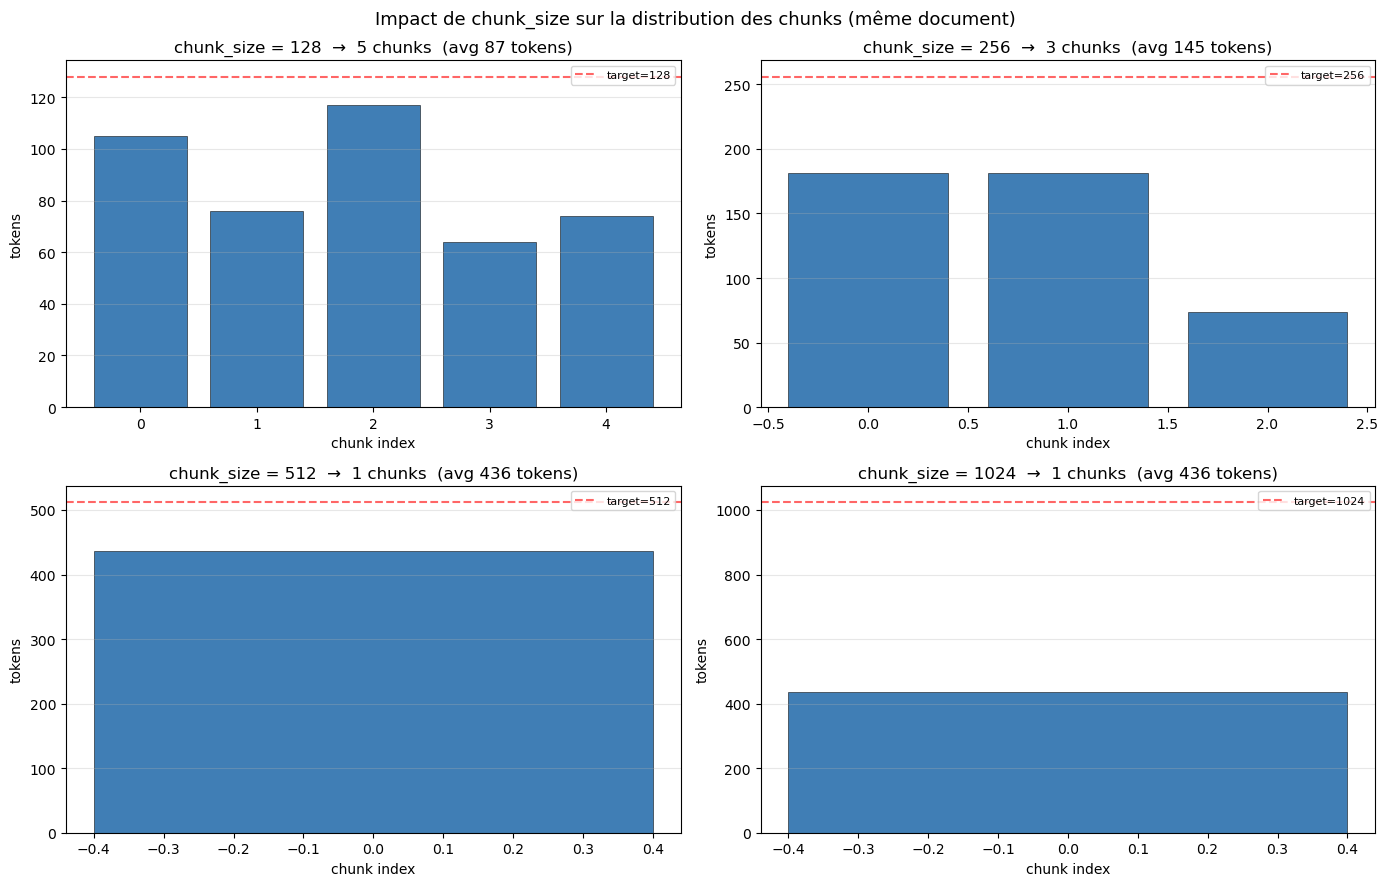

Lecture : plus chunk_size augmente, moins on a de chunks mais chacun est plus long.
Trop petit → contexte fragmenté ; trop grand → embedding flou et bruit au retrieval.


In [11]:
# ─── Comparaison visuelle : impact de chunk_size sur le découpage ─────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
test_sizes = [128, 256, 512, 1024]

sample_doc = all_documents[1]  # un document de référence

for ax, cs in zip(axes.flat, test_sizes):
    splitter_n = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        encoding_name="cl100k_base",
        chunk_size=cs,
        chunk_overlap=int(cs * 0.1),
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    sub = splitter_n.split_documents([sample_doc])
    sizes_n = [count_tokens(c.page_content) for c in sub]
    ax.bar(range(len(sizes_n)), sizes_n, color="#00539C", alpha=0.75,
           edgecolor="black", linewidth=0.5)
    ax.axhline(y=cs, color="red", linestyle="--", alpha=0.6, label=f"target={cs}")
    ax.set_title(f"chunk_size = {cs}  →  {len(sub)} chunks  (avg {np.mean(sizes_n):.0f} tokens)")
    ax.set_xlabel("chunk index")
    ax.set_ylabel("tokens")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Impact de chunk_size sur la distribution des chunks (même document)",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Lecture : plus chunk_size augmente, moins on a de chunks mais chacun est plus long.")
print("Trop petit → contexte fragmenté ; trop grand → embedding flou et bruit au retrieval.")


### 2.6 Démo : chunking structure-aware (Markdown)

`MarkdownHeaderTextSplitter` ne coupe **pas par tokens** : il découpe au **changement de titre**. Chaque chunk hérite alors de ses titres parents en métadonnées (`h1`, `h2`, `h3`) — utile pour reconstruire le contexte hiérarchique au moment du prompt.

**Pattern de production** : combiner les deux étages — d'abord `MarkdownHeaderTextSplitter` (préserve la structure), puis `RecursiveCharacterTextSplitter` sur chaque section trop longue (respecte `chunk_size`).


In [12]:
# ─── Démo MarkdownHeaderTextSplitter sur un fichier MD ────────────────────
md_path = sample_docs_dir / "transformers.md"
md_text = md_path.read_text(encoding="utf-8")

header_chunks = header_splitter.split_text(md_text)
print(f"{len(header_chunks)} chunks structurels (un par section)")
for hc in header_chunks:
    headers = " > ".join(v for k, v in hc.metadata.items() if k.startswith("h"))
    print(f"\n[{headers}]  ({count_tokens(hc.page_content)} tokens)")
    print(textwrap.shorten(hc.page_content, width=140, placeholder="..."))

# Pattern de production : MarkdownHeaderTextSplitter ▶ puis RecursiveCharacterTextSplitter
# pour respecter chunk_size sur les sections trop longues
combined_chunks = recursive_splitter.split_documents(header_chunks)
print(f"\nAprès second étage récursif : {len(combined_chunks)} chunks finaux")


14 chunks structurels (un par section)

[L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur > 1. Vue d'ensemble, Contexte Historique et Changement de Paradigme]  (816 tokens)
# L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur ## 1. Vue d'ensemble, Contexte Historique et...

[L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur > 2. L'Anatomie du Mécanisme de "Self-Attention" (Auto-Attention)]  (189 tokens)
## 2. L'Anatomie du Mécanisme de "Self-Attention" (Auto-Attention) Le cœur battant du Transformer, et l'innovation qui lui confère toute...

[L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur > 2. L'Anatomie du Mécanisme de "Self-Attention" (Auto-Attention) > 2.1. Requêtes (Queries), Clés (Keys) et Valeurs (Values) : L'Analogie de la Recherche]  (407 tokens)
### 2.1. Requêtes (Queries), Clés (Keys) et Valeurs (Values) : L'Analogie de la Recherche Pour chaque to

## Étape 3 — Embeddings (représentation vectorielle)

> **Concept clé** — Un *embedding* est une fonction $f : \text{texte} \to \mathbb{R}^d$ qui projette un texte dans un espace vectoriel où la **proximité géométrique reflète la proximité sémantique**.

### 3.1 Bi-encoder (modèle utilisé en RAG)

En RAG, on utilise typiquement des **Bi-encoders** : le **même modèle** encode indépendamment :
- chaque chunk **à l'indexation** (offline) → vecteur stocké
- la requête **à l'inférence** (online) → vecteur comparé

```
Chunk    ──▶ [ Encoder f ] ──▶ vecteur c ∈ ℝᵈ   (calculé une fois)
Requête  ──▶ [ Encoder f ] ──▶ vecteur q ∈ ℝᵈ   (calculé à chaque appel)
                                    │
                                    ▼
                              sim(q, c)  ──▶  top-k
```

> **Important** — Le **même modèle** doit être utilisé à l'indexation et à la requête. Changer de modèle d'embedding **invalide tout l'index** : il faut tout ré-embedder.


### 3.2 Métriques de similarité

Trois métriques principales pour comparer deux vecteurs $\mathbf{q}$ et $\mathbf{c}$ :

| Métrique | Formule | Propriétés |
|---|---|---|
| **Cosine similarity** | $\cos(\mathbf{q}, \mathbf{c}) = \dfrac{\mathbf{q} \cdot \mathbf{c}}{\|\mathbf{q}\| \, \|\mathbf{c}\|}$ | Insensible à la magnitude, ∈ [-1, 1] |
| **Dot product** | $\mathbf{q} \cdot \mathbf{c} = \sum_i q_i c_i$ | Sensible à la magnitude (utile si la norme code l'importance) |
| **Distance euclidienne (L2)** | $\|\mathbf{q} - \mathbf{c}\|_2 = \sqrt{\sum_i (q_i - c_i)^2}$ | Distance géométrique, peu utilisée en RAG |


> **Astuce production** — On **L2-normalise** systématiquement les vecteurs ($\|\mathbf{v}\| = 1$). Dans ce cas : **cosine = dot product** et **$L_2^2 = 2(1 - \cos)$**. Une seule métrique implémentée, trois interprétations équivalentes.

> **Cohérence avec l'entraînement** — La métrique choisie doit **correspondre à celle utilisée à l'entraînement du modèle**. La plupart des `sentence-transformers` sont entraînés en cosinus.

### 3.3 Choix d'un modèle d'embedding — le [MTEB Benchmark](https://huggingface.co/spaces/mteb/leaderboard)

**MTEB** (*Massive Text Embedding Benchmark*) est le leaderboard de référence : il évalue les modèles sur **56 datasets** dans 8 catégories (retrieval, classification, clustering, STS…). À consulter avant tout choix.

### 3.4 Critères de choix d'un modèle

| Critère | Pourquoi ça compte |
|---|---|
| **Multilingue** | Si votre corpus est en FR/AR/multi-langue, un modèle EN-only (ex. `all-MiniLM`) sous-performe |
| **Performance vs latence** | Modèle lourd (1B params) → meilleure qualité, mais latence × 10 |
| **Local vs API** | Local = gratuit + RGPD-friendly ; API = qualité top mais coût + dépendance |
| **Dimensions** ($d$) | Plus $d$ est grand, plus le modèle peut coder de nuance — mais l'index est plus lourd |
| **`max_input_tokens`** | **Doit être ≥ `chunk_size`** sinon votre chunk est tronqué silencieusement à l'embedding ! |
| **Taille du modèle** | Impacte la RAM et la vitesse à l'inférence |

### 3.5 Modèles open-source courants

| Modèle | Dimensions | `max_tokens` | Multilingue | Notes |
|---|---|---|---|---|
| `sentence-transformers/all-MiniLM-L6-v2` | 384 | 256 | ❌ EN | Rapide, léger, **bon défaut** |
| `sentence-transformers/all-mpnet-base-v2` | 768 | 384 | ❌ EN | +qualité, +lent |
| `intfloat/multilingual-e5-large` | 1024 | 512 | ✅ 100 langues | Excellent multilingue |
| `BAAI/bge-large-en-v1.5` | 1024 | 512 | ❌ EN | Top MTEB en open-source |
| `BAAI/bge-m3` | 1024 | 8192 | ✅ 100 langues | Long contexte + multilingue |
| `text-embedding-3-large` (OpenAI) | 3072 | 8191 | ✅ | Top qualité, payant |

Pour ce TP : `all-MiniLM-L6-v2` ($d=384$) — léger, rapide, sans clé API.


In [13]:
from sentence_transformers import SentenceTransformer

# Load a lightweight open-source embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimensions: {embed_model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {embed_model.max_seq_length}")

Model: all-MiniLM-L6-v2
Embedding dimensions: 384
Max sequence length: 256


### 3.6 Démo : l'espace vectoriel réagit-il bien à la sémantique ?

On embedde 3 phrases et on calcule les 3 métriques pour vérifier que l'espace vectoriel **rapproche** une phrase et sa paraphrase, et **éloigne** un sujet opposé ou différent.


In [14]:
# ─── Démo : similarité entre phrase / paraphrase / sujet différent ───────────
from numpy.linalg import norm

phrase_a   = "A transformer model uses self-attention to capture long-range dependencies."
phrase_a2  = "Transformers leverage attention mechanisms to model relations across distant tokens."  # paraphrase
phrase_b   = "Tomato sauce is essential for a good pasta dish."  # sujet différent

embs = embed_model.encode([phrase_a, phrase_a2, phrase_b], normalize_embeddings=False)
qa, qa2, qb = embs

def cosine(u, v): return float(np.dot(u, v) / (norm(u) * norm(v)))
def dot_p(u, v):  return float(np.dot(u, v))
def l2(u, v):     return float(norm(u - v))

pairs = [
    ("A vs paraphrase A'", qa, qa2),
    ("A vs sujet différent B", qa, qb),
    ("paraphrase A' vs B", qa2, qb),
]

header = ("Pair", "cosine", "dot", "L2")
print(f"{header[0]:<28} {header[1]:>8}  {header[2]:>8}  {header[3]:>8}")
print("-" * 60)
for name, u, v in pairs:
    print(f"{name:<28} {cosine(u, v):>8.3f}  {dot_p(u, v):>8.3f}  {l2(u, v):>8.3f}")



print("\nAnalyse des résultats :")
print("  • cosine == dot : Prouve que le modèle choisi, all-MiniLM-L6-v2, normalise ses vecteurs nativement (norme = 1),")
print("                    même si 'normalize_embeddings=False' a été précisé.")
print("  • A vs A' (Paraphrase) : Cosinus élevé (~0.69) et L2 faible (~0.79). Le modèle a bien")
print("                           compris que le sens est très similaire.")
print("  • vs Sujet B (Tomate) : Cosinus proche de 0. Les vecteurs pointent dans des directions")
print("                          orthogonales (sujets totalement décorrélés).")
print("  • L2 pour B : Proche de √2 (≈ 1.414), qui est la distance mathématique exacte entre")
print("                deux vecteurs de longueur 1 formant un angle de 90 degrés.")

Pair                           cosine       dot        L2
------------------------------------------------------------
A vs paraphrase A'              0.689     0.689     0.789
A vs sujet différent B          0.067     0.067     1.366
paraphrase A' vs B             -0.007    -0.007     1.419

Analyse des résultats :
  • cosine == dot : Prouve que le modèle choisi, all-MiniLM-L6-v2, normalise ses vecteurs nativement (norme = 1),
                    même si 'normalize_embeddings=False' a été précisé.
  • A vs A' (Paraphrase) : Cosinus élevé (~0.69) et L2 faible (~0.79). Le modèle a bien
                           compris que le sens est très similaire.
  • vs Sujet B (Tomate) : Cosinus proche de 0. Les vecteurs pointent dans des directions
                          orthogonales (sujets totalement décorrélés).
  • L2 pour B : Proche de √2 (≈ 1.414), qui est la distance mathématique exacte entre
                deux vecteurs de longueur 1 formant un angle de 90 degrés.


In [15]:
# ─── Embedding de tous les chunks ─────────────────────────────────────────
chunk_texts = [c.page_content for c in all_chunks]
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True, normalize_embeddings=True)

print(f"\nEmbeddings shape : {embeddings.shape}")
print(f"Chaque chunk est un vecteur de dimension {embeddings.shape[1]}.")
print(f"Vecteurs L2-normalisés → cosine similarity = dot product.")


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Embeddings shape : (66, 384)
Chaque chunk est un vecteur de dimension 384.
Vecteurs L2-normalisés → cosine similarity = dot product.


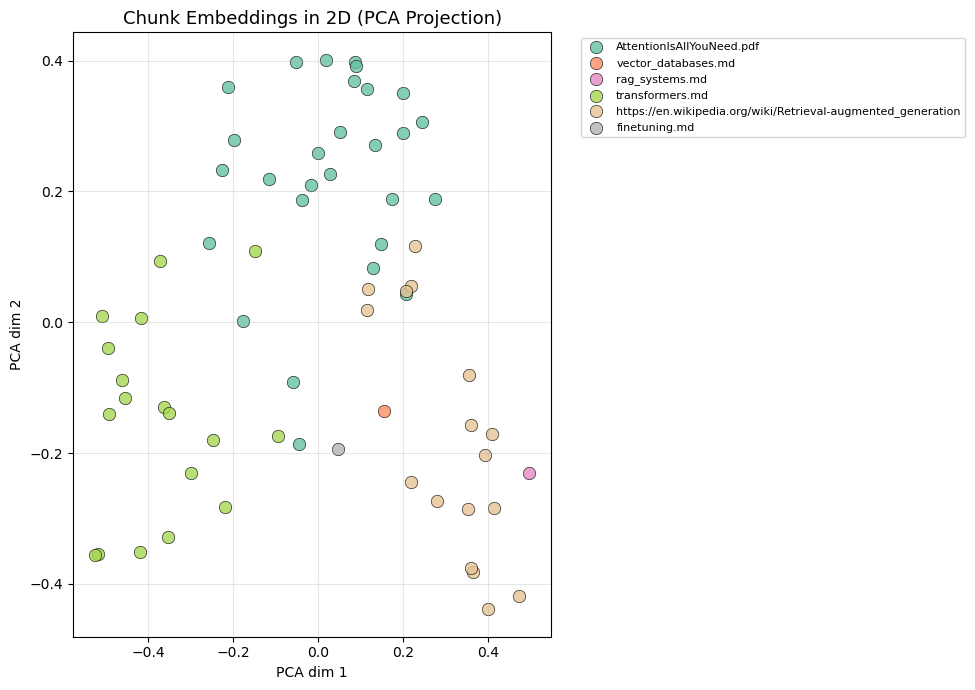

Chunks from the same document tend to cluster together in embedding space.
Thematically related chunks from different documents may also be close.


In [16]:
# ── Visualize embedding space ─────────────────────────────────────────────
# Use PCA to project 384D → 2D for visualization (safer on Apple Silicon than t-SNE)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

# Color by source document
sources = [c.metadata.get("source", "unknown") for c in all_chunks]
unique_sources = list(set(sources))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_sources)))
source_to_color = {s: colors[i] for i, s in enumerate(unique_sources)}

fig, ax = plt.subplots(figsize=(10, 7))
for source in unique_sources:
    mask = [s == source for s in sources]
    points = embeddings_2d[mask]
    ax.scatter(points[:, 0], points[:, 1], c=[source_to_color[source]],
               label=source, s=80, edgecolors="black", linewidth=0.5, alpha=0.8)

ax.set_title("Chunk Embeddings in 2D (PCA Projection)", fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Chunks from the same document tend to cluster together in embedding space.")
print("Thematically related chunks from different documents may also be close.")


## Étape 4 — Vector Storage & Search Index

> **Concept clé** — Une recherche **exhaustive** (comparer la requête à *tous* les vecteurs) est en $\mathcal{O}(N \cdot d)$ : impraticable au-delà du million de vecteurs. On utilise donc des **index ANN** (*Approximate Nearest Neighbor*) qui sacrifient un peu de recall pour gagner des **ordres de grandeur** en latence.

### 4.1 Recherche exacte vs ANN

| Approche | Complexité | Recall | Quand l'utiliser |
|---|---|---|---|
| **Brute-force** (exact) | $\mathcal{O}(N \cdot d)$ par requête | 100 % | < 10 k vecteurs, ou benchmarks |
| **HNSW** (graphe) | $\mathcal{O}(\log N)$ | 95–99 % | Défaut production |
| **IVF** (clustering) | $\mathcal{O}(\sqrt{N})$ | 90–95 % | Très grands corpus, mémoire limitée |
| **PQ / OPQ** (quantification) | Combiné avec IVF | 80–90 % | Compression, milliards de vecteurs |

### 4.2 HNSW — *Hierarchical Navigable Small World*

Construit un **graphe multi-couches** :
- la couche du haut a **peu** de nœuds avec des liens **longs** (navigation rapide)
- les couches du bas ont **tous** les nœuds avec des liens **courts** (raffinement précis)

```
Layer 2  ●─────────────────────●          (sparse, long-range)
         │                     │
Layer 1  ●───●──────●───●──────●          (medium)
         │   │      │   │      │
Layer 0  ●─●─●─●─●─●─●─●─●─●─●─●          (dense, short-range)
```

La recherche descend de couche en couche en suivant le voisin le plus proche.

**Hyperparamètres clés** :
- `M` : nombre de connexions par nœud (typique : 16–64). $\uparrow M \Rightarrow$ +recall, +RAM
- `ef_construction` : qualité du graphe à la construction (typique : 100–400)
- `ef_search` : profondeur de recherche à la requête (typique : 50–200)

### 4.3 IVF — *Inverted File Index*

1. **k-means** sur les vecteurs → on obtient $K$ centroïdes (clusters).
2. À l'indexation : chaque vecteur est attaché à son centroïde le plus proche.
3. À la requête : on identifie les `n_probe` clusters les plus proches de $\mathbf{q}$, et on cherche **uniquement** dans ceux-là.

**Hyperparamètres** :
- `nlist` (= $K$) : nombre de clusters (typique : $\sqrt{N}$)
- `nprobe` : nombre de clusters explorés par requête (compromis recall/vitesse)

### 4.4 Comparaison HNSW vs IVF

| Critère | HNSW | IVF |
|---|---|---|
| Recall à latence égale | ✅ Meilleur | ⚠️ Inférieur |
| Empreinte mémoire | ❌ Lourde (graphe) | ✅ Légère |
| Insertion incrémentale | ✅ Rapide | ❌ Coûteuse (re-clustering) |
| Très grands corpus (>100M) | ⚠️ RAM-bound | ✅ Combiné avec PQ |

**Règle pratique** : commencer en **HNSW** ; passer à **IVF + PQ** uniquement si la mémoire devient un problème.

### 4.5 Écosystème des Vector DBs

| Vector DB | Type | Forces | Quand choisir |
|---|---|---|---|
| **FAISS** (Meta) | Bibliothèque (in-process) | Le plus rapide, GPU, large gamme d'index | Recherche, batch offline |
| **Chroma** | Embedded / serveur léger | API simple, démarrage instantané | **Prototypage, ce TP** |
| **Qdrant** | Serveur (Rust) | Excellent filtrage, gRPC, payloads riches | Production, RAG complexe |
| **Milvus** | Serveur distribué | Très scalable, multi-index, multi-tenant | Très gros corpus (≥ 100M) |
| **Pinecone** | Managed cloud | Serverless, zéro ops, filtrage métadonnées | Démarrage rapide, équipe ops réduite |
| **Weaviate** | Serveur, GraphQL | Hybride natif, modules ML intégrés | Hybride out-of-the-box |
| **pgvector** | Extension Postgres | Tout dans la DB existante | Stack PG existante, < 1M vecteurs |

> **Pour ce TP** — On utilise **Chroma** (in-memory, zéro install serveur, index HNSW intégré).


In [17]:
import chromadb

# ─── Index vectoriel (ChromaDB) ────────────────────────────────────────────
chroma_client = chromadb.Client()  # in-memory pour ce TP

collection = chroma_client.create_collection(
    name="rag_lab",
    metadata={"hnsw:space": "cosine"}    # similarité cosinus (cf. § 3.3)
)

# Ajout des chunks dans Chroma — Chroma exige des metadata sérialisables
def _flatten_meta(m):
    return {k: (v if isinstance(v, (str, int, float, bool)) else str(v))
            for k, v in m.items()}

collection.add(
    ids=[c.metadata["chunk_id"] for c in all_chunks],
    embeddings=embeddings.tolist(),
    documents=chunk_texts,
    metadatas=[_flatten_meta(c.metadata) for c in all_chunks],
)

print(f"ChromaDB collection '{collection.name}' : {collection.count()} vecteurs")




ChromaDB collection 'rag_lab' : 66 vecteurs


## Phase Online Étape 1 & 2 — Query Embedding & Retrieval top-k (dense retrieval)

> **Concept clé** — Nous utilisons le même modèle d'embedding que celui utilisé dans la phase des documents embeddings, pour encoder la question de l'utilisateur. 
Aucune méthode de retrieval n'est universelle. Le **dense retrieval** comprend la sémantique, et capture les chunks les plus similaires à la requête de l'utilisateur mais peut rater un mot-clé exact. Nous reviendrons après pour proposer une autre méthode de retrieval pour palier à cette limitation.

In [18]:
def retrieve_dense(query: str, top_k: int = 5):
    """Retrieval dense : similarité vectorielle (ChromaDB)."""
    query_embedding = embed_model.encode([query], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [
        {"text": doc, "metadata": meta, "score": 1 - dist, "method": "dense"}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ]

print("Fonction de retrieval dense définie.")


Fonction de retrieval dense définie.


## Phase Online Étape 3 — Augmentation du prompt

L'augmentation insère les chunks récupérés dans un prompt template soigneusement conçu. Principes clés :

1. **Répondre UNIQUEMENT à partir du contexte fourni** — prévient les hallucinations
2. **Citer les sources** — permet la vérification et la confiance
3. **Repli explicite** — dire « preuves insuffisantes » plutôt que de deviner
4. **Structurer le contexte** — inclure les métadonnées (source, section) pour que le LLM sache d'où vient l'information

In [19]:
def build_rag_prompt(query: str, retrieved_chunks: List[Dict]) -> str:
    """Build a RAG prompt with retrieved context and citation instructions."""
    # Format context blocks with metadata
    context_blocks = []
    for i, chunk in enumerate(retrieved_chunks):
        source = chunk["metadata"].get("source", "unknown")
        section = chunk["metadata"].get("section", "")
        chunk_id = f"{source}:{section}" if section else source
        context_blocks.append(
            f"[Source {i+1}: {chunk_id}]\n{chunk['text']}"
        )

    context_str = "\n\n---\n\n".join(context_blocks)

    prompt = f"""You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
{context_str}

Question: {query}

Answer:"""
    return prompt


In [20]:
# ── Build a prompt for our query ──────────────────────────────────────────
query = "What are the different chunking strategies for RAG and when should I use each?"
retrieved = retrieve_dense(query, top_k=5)

prompt = build_rag_prompt(query, retrieved)
print(f"Prompt length: {count_tokens(prompt)} tokens\n")
print(prompt[:1500])
print("\n... [truncated for display]")

Prompt length: 2408 tokens

You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
[Source 1: rag_systems.md]
# Retrieval-Augmented Generation

## Definition
Retrieval-Augmented Generation (RAG) combines an information retrieval layer with
a language model so that responses are generated from retrieved evidence instead
of relying only on parametric memory. The canonical paper by Lewis et al. (2020)
introduced this paradigm for knowledge-intensive NLP tasks.

RAG systems split knowledge into parametric memory (model weights, frozen at
training time) and non-parametric memory (document index, updatable at any time).

## Why RAG Matters
Pure LLMs suffer from knowledge cutoff, hallucinations under 

## Étape 8 — Génération par LLM

Étape finale : on envoie le prompt augmenté à un LLM pour générer une **réponse ancrée et citée**.

Nous utilisons **`llama-3.3-70b-versatile` via l'API Groq** — modèle 70 milliards de paramètres, **gratuit** via le tier free de Groq, avec une **inférence ultra-rapide** grâce aux LPUs.

> **Pourquoi ce choix ?** L'API est **OpenAI-compatible** : le code est trivialement portable vers OpenAI, Azure OpenAI, Mistral, ou Anthropic. Llama 3.3 70B suit très bien les instructions et produit du JSON propre — utile pour la partie Graph RAG (extraction d'entités).
>
> **Configurer la clé** : voir cellule 0 → https://console.groq.com → *API Keys*.


In [21]:
def generate_answer(prompt: str, model: str = LLM_MODEL) -> str:
    """Generate an answer using llama-3.3-70b-versatile via Groq (free tier)."""
    if not API_AVAILABLE:
        return "[LLM call skipped — define GROQ_API_KEY first.]"
    try:
        response = llm_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,   # Low temperature for factual answers
            max_tokens=500,
        )
        return response.choices[0].message.content
    except Exception as e:
        return (f"[LLM call failed: {e}]\n\n"
                "Vérifier que GROQ_API_KEY est bien définie. "
                "Créer une clé sur https://console.groq.com")


# ─── Full RAG Pipeline: end-to-end ─────────────────────────────────────────
def rag_pipeline(query: str, top_k: int = 5):
    """Run the complete RAG pipeline."""
    # Step 1: Retrieve
    retrieved = retrieve_dense(query, top_k=top_k)

    # Step 2: Build prompt
    prompt = build_rag_prompt(query, retrieved)

    # Step 3: Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "retrieved_chunks": retrieved,
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print(f"Full RAG pipeline ready (using {LLM_MODEL} via Groq).")


Full RAG pipeline ready (using llama-3.3-70b-versatile via Groq).


In [22]:
# ── Test the full RAG pipeline with multiple queries ──────────────────────
test_queries = [
    "What chunking strategies are used in RAG systems and when should I use each?",
    "How does HNSW work and what are its key parameters?",
    "When should I use RAG vs fine-tuning?",
    "What is the difference between sparse and dense retrieval?",
    "What is quantum computing?",  # Out of scope — should trigger fallback
]

for q in test_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")
    result = rag_pipeline(q)
    print(f"\nSources used:")
    for i, c in enumerate(result["retrieved_chunks"]):
        print(f"  [{i+1}] {c['metadata'].get('source', '?')} — {c['metadata'].get('format', '?')}")
    print(f"\nAnswer ({result['prompt_tokens']} prompt tokens):")
    print(result["answer"])


Q: What chunking strategies are used in RAG systems and when should I use each?

Sources used:
  [1] rag_systems.md — markdown
  [2] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web
  [4] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web
  [5] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web

Answer (2408 prompt tokens):
According to [Source 1], chunking strategies in RAG systems include: 
- Fixed-size (token-based): window of 256-512 tokens with 10-20% overlap, 
- Recursive splitting: split by hierarchical separators (paragraphs, sentences), 
- Semantic chunking: segment by embedding similarity between adjacent passages, 
- Document-aware: respect document structure (headings, sections, code blocks). 
The optimal chunk size depends on the use case: smaller chunks (256 tokens) favor precision, while larger chunks (1024 tokens) preserve more context [Source 1]. 

---

# PARTIE B — Advanced RAG (45 min)

> **De prototype à outil robuste.** Le pipeline Basic RAG fonctionne, mais souffre de plusieurs **limitations connues** qu'on va attaquer une à une.


## B.1 Contextual Retrieval (Anthropic, 2024)

> **Idée** — Un chunk extrait isolément perd souvent son contexte global. *Exemple : « Le ROI a augmenté de 12 % » — mais de quelle entreprise, quelle année ?*

**Recette** : avant l'embedding, demander à un LLM de **préfixer chaque chunk** d'un court résumé de la section parente :

```
Original chunk    : "Le ROI a augmenté de 12 % au T3."
Contextualisé     : "[Acme Corp · Rapport annuel 2024 · Performance financière]
                     Le ROI a augmenté de 12 % au T3."
```
Coût : un appel LLM par chunk à l'indexation (faisable car offline).

### Démo : Contextual Retrieval (préfixage par LLM)

On construit pour chaque chunk un **court préfixe contextuel** généré par le LLM, qui résume **où** le chunk se situe dans le document parent. Ce préfixe est concaténé avant l'embedding et avant l'indexation.

**Coût** : 1 appel LLM par chunk (offline). **Bénéfice** : retrieval significativement plus robuste sur les corpus où les chunks isolés sont ambigus (rapports, contrats, transcripts).

In [23]:
# ─── Contextual Retrieval : préfixage de chaque chunk par un résumé contextuel ─
CONTEXTUAL_PROMPT = """<document>
{document}
</document>

Voici un chunk extrait de ce document :
<chunk>
{chunk}
</chunk>

Donne UNIQUEMENT un court contexte (1-2 phrases, max 50 tokens) qui situe ce chunk dans le document global, pour améliorer la recherche. Pas d'introduction, pas de formatage."""


def contextualize_chunk(chunk_text: str, parent_text: str, model: str = LLM_MODEL) -> str:
    """Renvoie le chunk préfixé d'un court contexte généré par LLM (Groq)."""
    if not API_AVAILABLE:
        return chunk_text
    try:
        resp = llm_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": CONTEXTUAL_PROMPT.format(
                document=parent_text[:4000], chunk=chunk_text)}],
            temperature=0.0,
            max_tokens=80,
        )
        ctx = resp.choices[0].message.content.strip()
        return f"[Contexte: {ctx}]\n\n{chunk_text}"
    except Exception:
        return chunk_text


# Démo sur 2 chunks (l'opération est coûteuse → on ne contextualise pas tout le corpus ici)
parent = all_documents[2].page_content  # transformers.md
sample_chunks = [c for c in all_chunks if c.metadata.get("source") == "transformers.md"][:2]

print("=== Avant Contextual Retrieval ===")
for c in sample_chunks:
    snippet = textwrap.shorten(c.page_content, width=200, placeholder='...')
    print(f"\n• {snippet}")

print("\n=== Après Contextual Retrieval ===")
for c in sample_chunks:
    enriched = contextualize_chunk(c.page_content, parent)
    snippet = textwrap.shorten(enriched, width=300, placeholder='...')
    print(f"\n• {snippet}")

print("\nNote : pour cette démo on n'applique PAS la contextualisation à tout le corpus")
print("(coût LLM × N chunks). En production, c'est un job offline avant indexation.")


=== Avant Contextual Retrieval ===

• # L'Architecture Transformer : Une Plongée Analytique et Mathématique en Profondeur ## 1. Vue d'ensemble, Contexte Historique et Changement de Paradigme Avant la publication révolutionnaire de la...

• Cependant, cette approche se heurtait à deux murs architecturaux infranchissables : Premièrement, le **goulot d'étranglement de l'information**. Forcer une phrase entière, potentiellement très...

=== Après Contextual Retrieval ===

• [Contexte: Ce chunk est extrait de l'introduction du document, qui présente le contexte historique du traitement du langage naturel avant l'avènement de l'architecture Transformer. Il fait partie de la section 1, "Vue d'ensemble, Contexte Historique et Changement de Paradigme".] # L'Architecture...

• [Contexte: Le document décrit les limites des Réseaux de Neurones Récurrents (RNN) dans le traitement du langage naturel, notamment en traduction automatique. Cette section présente les deux principaux problèmes auxquels l

## B.2 — Query Rewriting

> **Idée** — La requête utilisateur est souvent **trop courte**, **mal formulée**, ou contient du **bruit conversationnel** (« euh, en fait je voulais savoir… »). On demande au LLM de **réécrire** la question en une formulation **canonique** avant retrieval.

### Quand c'est utile

- Requêtes vagues : *« et HNSW ? »* → *« Comment fonctionne l'algorithme HNSW pour la recherche approximative de plus proches voisins ? »*
- Requêtes conversationnelles avec historique : on incorpore le contexte des tours précédents
- Requêtes en langage naturel à transformer en formulation technique

### Coût / bénéfice

- 1 appel LLM supplémentaire (latence ↑)
- Gain typique sur les requêtes courtes : **+5 à +15 % de Recall@k**


In [24]:
# ─── Query Rewriting via LLM ───────────────────────────────────────────────
REWRITE_PROMPT = """Tu réécris une requête utilisateur pour qu'elle soit plus efficace en recherche documentaire.
Garde le sens, élimine le bruit conversationnel, ajoute les termes techniques implicites.
Renvoie UNIQUEMENT la requête réécrite, sans préambule.

Requête originale : {query}

Requête réécrite :"""


def rewrite_query(query: str) -> str:
    if not API_AVAILABLE:
        return query
    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": REWRITE_PROMPT.format(query=query)}],
            temperature=0.0,
            max_tokens=80,
        )
        return resp.choices[0].message.content.strip().strip('"').strip("'")
    except Exception:
        return query


queries_to_rewrite = [
    "et HNSW c'est quoi ?",
    "comment ça marche le LoRA truc",
    "different chunking",
]
for q in queries_to_rewrite:
    print(f"Original  : {q}")
    print(f"Réécrite  : {rewrite_query(q)}\n")


Original  : et HNSW c'est quoi ?
Réécrite  : Définition et fonctionnement de l'algorithme HNSW (Hierarchical Navigable Small World) dans la recherche d'informations et l'indexation de données.

Original  : comment ça marche le LoRA truc
Réécrite  : Fonctionnement du modèle de langage LoRA (Low-Rank Adaptation) en intelligence artificielle

Original  : different chunking
Réécrite  : Segmentation de données en blocs ou chunking de données



## B.3 — Multi-Query Retrieval

> **Idée** — Une seule formulation = un seul angle de recherche. On demande au LLM de **générer N variantes** de la requête (synonymes, reformulations, sous-questions), on **récupère pour chacune**, et on **fusionne avec RRF**.

### Pourquoi ça marche

- Compense le **vocabulary mismatch** entre requête et documents
- Récupère des chunks pertinents que la requête originale n'aurait pas atteints
- Coût : N appels au retriever (mais retrievers parallélisables)

### Schéma

```
Requête originale
        │
        ▼
   [LLM génère 3-5 variantes]
        │
   ┌────┼────┬────┐
   ▼    ▼    ▼    ▼
[ret][ret][ret][ret]    ← retrieve_dense en parallèle
   │    │    │    │
   └────┴─RRF─┴────┘
        │
        ▼
   chunks fusionnés
```

### Reciprocal Rank Fusion (RRF)

On fusionne les classements des différents chunks récupérés en utilisant **leurs rangs** :

$$
\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}
$$

avec $k = 60$ (constante standard, lisse les contributions). Robuste, sans calibration, recommandé en production.


In [25]:
# ─── Multi-Query Retrieval avec fusion RRF ─────────────────────────────────
MULTIQUERY_PROMPT = """Génère exactement 3 reformulations alternatives de la requête ci-dessous, qui couvrent des angles différents (synonymes, sous-questions, niveau d'abstraction).
Réponds UNIQUEMENT par les 3 reformulations, une par ligne, sans numérotation ni préambule.

Requête : {query}"""


def generate_query_variants(query: str, n: int = 3):
    if not API_AVAILABLE:
        return [query]
    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": MULTIQUERY_PROMPT.format(query=query)}],
            temperature=0.4,
            max_tokens=200,
        )
        text = resp.choices[0].message.content.strip()
        variants = [l.strip(" -•\t") for l in text.split("\n") if l.strip()]
        return variants[:n] if variants else [query]
    except Exception:
        return [query]


def retrieve_multi_query(query: str, top_k: int = 5, rrf_k: int = 60):
    """Multi-query retrieval : fusionne les résultats des reformulations via RRF."""
    variants = [query] + generate_query_variants(query, n=3)
    rrf_scores, doc_map = {}, {}
    for v in variants:
        results = retrieve_dense(v, top_k=top_k * 2)
        for rank, r in enumerate(results):
            key = r["text"][:100]
            rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
            doc_map[key] = r
    sorted_keys = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [{**doc_map[k], "score": rrf_scores[k], "method": "multi_query"} for k in sorted_keys], variants


q = "How to evaluate RAG?"
results, variants = retrieve_multi_query(q, top_k=3)

print(f"Requête originale : {q}")
print("Variantes générées :")
for v in variants[1:]:
    print(f"  • {v}")
print("\nTop-3 fusionné (RRF) :")
for r in results:
    snippet = textwrap.shorten(r['text'], 100, placeholder='...')
    print(f"  [{r['score']:.4f}] {snippet}")


Requête originale : How to evaluate RAG?
Variantes générées :
  • Comment évaluer la méthodologie RAG pour mesurer son efficacité ?
  • Quelles sont les métriques clés pour évaluer les performances de RAG dans différents contextes ?
  • Quels sont les indicateurs de réussite pour déterminer si RAG atteint ses objectifs ?

Top-3 fusionné (RRF) :
  [0.0479] * **Le KV-Cache (Key-Value Cache)** : Lors de la génération (inférence) token par token,...
  [0.0471] Cependant, cette approche se heurtait à deux murs architecturaux infranchissables : Premièrement,...
  [0.0325] 1. **L'Auto-Attention Masquée (Masked Multi-Head Self-Attention)** : Lors de l'entraînement, on...


## B.4 — HyDE (*Hypothetical Document Embeddings*)

> **Idée géniale** (Gao et al., 2022) — La requête et le document vivent dans des **espaces sémantiques différents** (question vs réponse). On comble le gap en demandant au LLM de **générer une RÉPONSE HYPOTHÉTIQUE** à la question, puis on **embedde cette réponse fictive** plutôt que la question.

### Pourquoi ça marche

Le LLM produit un texte qui **ressemble structurellement aux documents pertinents** (même registre, même vocabulaire technique). Sa similarité avec les vrais chunks est donc plus élevée que celle de la question brute.

### Pipeline

```
Question utilisateur
        │
        ▼
[LLM génère une réponse hypothétique (fausse, mais plausible)]
        │
        ▼
[Embedding de la RÉPONSE, pas de la question]
        │
        ▼
[Recherche dans le vector store]
        │
        ▼
[Top-k]  ─→ on génère ENSUITE la vraie réponse, ancrée
```

### Limite

Le LLM peut **halluciner** dans la réponse hypothétique — peu importe, on n'utilise que **son embedding**, pas son contenu. Mais sur des sujets très techniques inconnus du LLM, HyDE peut générer du bruit qui n'aide pas le retrieval.


In [26]:
# ─── HyDE : Hypothetical Document Embeddings ─────────────────────────────
HYDE_PROMPT = """Réponds en 2-3 phrases techniques à la question ci-dessous, comme si tu écrivais un extrait de documentation.
Peu importe que ta réponse soit exacte : on cherche juste un texte plausible et bien formulé.

Question : {query}

Réponse :"""


def hyde_retrieve(query: str, top_k: int = 5):
    """HyDE : génère une réponse hypothétique, l'embedde, puis cherche."""
    if API_AVAILABLE:
        try:
            resp = llm_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": HYDE_PROMPT.format(query=query)}],
                temperature=0.3,
                max_tokens=150,
            )
            hypothetical = resp.choices[0].message.content.strip()
        except Exception:
            hypothetical = query
    else:
        hypothetical = query

    # On embedde la RÉPONSE HYPOTHÉTIQUE, pas la question
    hyde_emb = embed_model.encode([hypothetical], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=hyde_emb,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [
        {"text": doc, "metadata": meta, "score": 1 - dist, "method": "hyde"}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ], hypothetical


q = "What is HNSW?"
results, hypo = hyde_retrieve(q, top_k=3)
print(f"Question : {q}\n")
print("Réponse hypothétique générée (embeddée à la place de la question) :")
print(f"  {hypo}\n")
print("Top-3 récupéré via embedding de la réponse hypothétique :")
for r in results:
    snippet = textwrap.shorten(r['text'], 100, placeholder='...')
    print(f"  [{r['score']:.4f}] {snippet}")


Question : What is HNSW?

Réponse hypothétique générée (embeddée à la place de la question) :
  HNSW (Hierarchical Navigable Small World) est un algorithme d'indexation et de recherche d'approximation de plus proches voisins (ANN) qui utilise une structure de données hiérarchique pour améliorer l'efficacité de la recherche dans les espaces de grande dimension. Il s'appuie sur la construction d'un graphe de petite monde navigable pour réduire le nombre de calculs nécessaires à la recherche de similarité. Cela permet une recherche rapide et efficace dans les bases de données de grande taille.

Top-3 récupéré via embedding de la réponse hypothétique :
  [0.5500] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-dimensional...
  [0.3555] Chaque tête opère sur des dimensions réduites ($d_k = d_v = d_{model} / h = 512 / 8 = 64$), ce...
  [0.2831] Tout comme l'encodeur, chaque sous-module du décodeur est enveloppé par des connexions...


## B.5 — Recherche hybride + RRF

> **Concept clé** — Aucune méthode de retrieval n'est universelle. Le **dense** comprend la sémantique mais peut rater un mot-clé exact. Le **sparse** (BM25) excelle en lexical mais ignore les paraphrases. La solution : **les combiner**.

### B.5.1 Dense (vecteur) vs Sparse (BM25)

| Type | Forces | Faiblesses |
|---|---|---|
| **Dense** (cosinus sur embeddings) | Paraphrases, synonymes, langues, sens implicite | Mots rares (acronymes, codes produits, noms propres) |
| **Sparse** (BM25 / TF-IDF) | Mots-clés exacts, rapidité, interprétable | Synonymes, paraphrases, polysémie |
| **Hybride** | Le meilleur des deux | Plus de complexité (réglage RRF) |

### B.5.2 Rappel formule BM25

Pour une requête $Q = \{q_1, \dots, q_n\}$ et un document $D$ :

$$
\text{BM25}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \, (k_1 + 1)}{f(q_i, D) + k_1 \left(1 - b + b \cdot \dfrac{|D|}{\text{avgdl}}\right)}
$$

où $f(q_i, D)$ est la fréquence du terme dans $D$, $|D|$ la longueur du document, et $k_1, b$ des hyperparamètres ($k_1 \approx 1.5$, $b \approx 0.75$).

### B.5.3 Reciprocal Rank Fusion (RRF)

On fusionne les classements en **ignorant les scores absolus** (qui ne sont pas comparables entre dense et sparse) — on n'utilise que **les rangs** :

$$
\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}
$$

avec $k = 60$ (constante standard, lisse les contributions). Robuste, sans calibration, recommandé en production.


Nous devons tout d'abord créer l'index BM25 (embeddings sparses de nos chunks)

In [27]:
from rank_bm25 import BM25Okapi

# ─── Index BM25 (sparse) ───────────────────────────────────────────────────
tokenized_chunks = [text.lower().split() for text in chunk_texts]
bm25_index = BM25Okapi(tokenized_chunks)

print(f"Index BM25 : {len(tokenized_chunks)} documents indexés")

Index BM25 : 66 documents indexés


In [28]:
# Fonction déjà définie auparavant
# def retrieve_dense(query: str, top_k: int = 5):
#     """Retrieval dense : similarité vectorielle (ChromaDB)."""
#     query_embedding = embed_model.encode([query], normalize_embeddings=True).tolist()
#     results = collection.query(
#         query_embeddings=query_embedding,
#         n_results=top_k,
#         include=["documents", "metadatas", "distances"]
#     )
#     return [
#         {"text": doc, "metadata": meta, "score": 1 - dist, "method": "dense"}
#         for doc, meta, dist in zip(
#             results["documents"][0], results["metadatas"][0], results["distances"][0]
#         )
#     ]


def retrieve_sparse(query: str, top_k: int = 5):
    """Retrieval sparse : BM25 (mots-clés)."""
    query_tokens = query.lower().split()
    scores = bm25_index.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [
        {"text": all_chunks[i].page_content, "metadata": all_chunks[i].metadata,
         "score": scores[i], "method": "sparse"}
        for i in top_indices if scores[i] > 0
    ]


def retrieve_hybrid(query: str, top_k: int = 5, rrf_k: int = 60):
    """Retrieval hybride avec Reciprocal Rank Fusion (RRF)."""
    dense_results = retrieve_dense(query, top_k=top_k * 2)
    sparse_results = retrieve_sparse(query, top_k=top_k * 2)

    rrf_scores, doc_map = {}, {}
    for rank, r in enumerate(dense_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r
    for rank, r in enumerate(sparse_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r

    sorted_keys = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [{**doc_map[k], "score": rrf_scores[k], "method": "hybrid"} for k in sorted_keys]


print("Fonctions de retrieval définies : dense, sparse, hybrid (RRF).")


Fonctions de retrieval définies : dense, sparse, hybrid (RRF).


In [29]:
# ── Demonstrate hybrid retrieval impact ──────────────────────────────────────────
query = "How does HNSW algorithm work for vector search?"
print(f"Query: '{query}'\n")

# Retrieve with dense
dense_results = retrieve_dense(query, top_k=5)
print("Chunks retrieved with Dense Retrieval:")
for i, r in enumerate(dense_results[:5]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=150, placeholder='...')}")

# Retrieve with sparse (BM25)
sparse_results = retrieve_sparse(query, top_k=5)
print("Chunks retrieved with Sparse Retrieval:")
for i, r in enumerate(sparse_results[:5]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=150, placeholder='...')}")

# Retrieve with hybrid
hybrid_results = retrieve_hybrid(query, top_k=5)
print("Chunks retrieved with Hybrid Retrieval:")
for i, r in enumerate(hybrid_results[:5]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=150, placeholder='...')}")

Query: 'How does HNSW algorithm work for vector search?'

Chunks retrieved with Dense Retrieval:
  #1 [0.6317] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-dimensional embeddings and enable fast approximate nearest...
  #2 [0.3869] Performance improves by optimizing how vector similarities are calculated. Dot products enhance similarity scoring, while approximate nearest...
  #3 [0.3121] RAG key stages[edit] Overview of RAG process, combining external documents and user input into an LLM prompt to get tailored output Typically, the...
  #4 [0.3041] linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the...
  #5 [0.2767] Scaled Dot-Product Attention Multi-Head Attention Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several...
Chunks retrieved with Sparse Retrieval:
  #1 [14.6547] # Vector Databases and Indexing ## Why 

## B.6 — Re-ranking (cross-encoder)

> **Concept clé** — Le retrieval optimise la **couverture** (rappel) en récupérant 20–50 candidats. Le re-ranking optimise la **précision** en sélectionnant les 3–5 meilleurs grâce à un modèle plus puissant.

### B.6.1 Bi-encoder vs Cross-encoder

C'est la distinction la plus importante de cette étape.

```
BI-ENCODER (utilisé en retrieval, § Étape 3)
    Query  ──▶ [ Encoder ] ──▶ q ∈ ℝᵈ
    Chunk  ──▶ [ Encoder ] ──▶ c ∈ ℝᵈ        score = sim(q, c)   (cosinus)

  ✓ Encode chaque chunk UNE SEULE FOIS (pré-calculé à l'indexation)
  ✓ Recherche en O(log N) via index ANN
  ✗ Pas d'attention CROISÉE entre la requête et le chunk

CROSS-ENCODER (utilisé en re-ranking)
    [ Query ; Chunk ]  ──▶ [ Encoder + Classifier ] ──▶ score ∈ ℝ

  ✓ Attention CROISÉE pleine entre les tokens de Q et ceux de C
    → bien plus précis (capture les nuances de la question)
  ✗ Doit re-passer le couple (Q, C) dans le modèle pour CHAQUE candidat
    → impraticable en retrieval (N candidats), parfait en re-ranking (k candidats)
```

### B.6.2 Pipeline two-stage standard

```
Requête
   │
   ▼
[Retrieval]  ── 20-50 candidats ── (Bi-encoder + BM25, rapide)
   │
   ▼
[Reranking]  ── 3-5 meilleurs ── (Cross-encoder, lent mais précis)
   │
   ▼
Prompt LLM
```

**Gain typique** : +10 à +30 % sur la *Faithfulness* (sans changer le LLM de génération), pour quelques dizaines de millisecondes ajoutées.

### B.6.3 Modèles de re-ranking courants

| Modèle | Type | Notes |
|---|---|---|
| `cross-encoder/ms-marco-MiniLM-L-6-v2` | Local, open | **Utilisé dans ce TP** — léger, rapide |
| `BAAI/bge-reranker-large` | Local, open | Top open-source, multilingue (`bge-reranker-v2-m3`) |
| **Cohere Rerank 3** | API hébergée | Très bonne qualité, API payante |
| `mixedbread-ai/mxbai-rerank-large-v1` | Local, open | Excellent, longue séquence |

> **Quand utiliser un re-ranking par LLM ?** Quand la nuance ou le raisonnement est nécessaire (juridique, médical, comparatif). Coût élevé : à réserver aux requêtes critiques.


In [30]:
from sentence_transformers import CrossEncoder

# Load cross-encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def rerank(query: str, results: List[Dict], top_k: int = 3) -> List[Dict]:
    """Rerank retrieved results using a cross-encoder."""
    if not results:
        return []
    pairs = [(query, r["text"]) for r in results]
    scores = reranker.predict(pairs)
    
    for r, score in zip(results, scores):
        r["rerank_score"] = float(score)
    
    reranked = sorted(results, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_k]


# ── Demonstrate reranking impact ──────────────────────────────────────────
query = "How does HNSW algorithm work for vector search?"
print(f"Query: '{query}'\n")

# Retrieve with hybrid
initial_results = retrieve_hybrid(query, top_k=8)
print("Before Reranking (Hybrid Retrieval):")
for i, r in enumerate(initial_results[:]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

# Rerank
reranked_results = rerank(query, initial_results, top_k=5)
print(f"\nAfter Reranking (Cross-Encoder):")
for i, r in enumerate(reranked_results[:5]):
    print(f"  #{i+1} [{r['rerank_score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

Query: 'How does HNSW algorithm work for vector search?'

Before Reranking (Hybrid Retrieval):
  #1 [0.0328] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-...
  #2 [0.0323] Performance improves by optimizing how vector similarities are calculated. Dot products...
  #3 [0.0310] RAG key stages[edit] Overview of RAG process, combining external documents and user...
  #4 [0.0296] output values. These are concatenated and once again projected, resulting in the final...
  #5 [0.0291] Chunking[edit] Chunking involves various strategies for breaking up the data into...
  #6 [0.0276] ^ Wang, Yup; Conroy, John M.; Molino, Neil; Yang, Julia; Green, Mike (2024)....
  #7 [0.0276] # LLM Fine-Tuning ## When to Fine-Tune vs RAG Fine-tuning modifies model weights to...
  #8 [0.0159] Challenges[edit] RAG does not prevent hallucinations in LLMs. According to Ars...

After Reranking (Cross-Encoder):
  #1 [5.9880] # Vector Databases and Indexing ## Why Vector Databases

In [31]:
# ─── Full RAG Pipeline: end-to-end with different retrieval method and reranking ─────────────────────────────────────────
def rag_pipeline_full(query: str, top_k: int = 5, rerank_top_k: int = 3,
                 use_reranking: bool = True, retrieval_method: str = "hybrid"):
    """Run the complete RAG pipeline."""
    # Step 1: Retrieve
    if retrieval_method == "dense":
        retrieved = retrieve_dense(query, top_k=top_k)
    elif retrieval_method == "sparse":
        retrieved = retrieve_sparse(query, top_k=top_k)
    else:
        retrieved = retrieve_hybrid(query, top_k=top_k)

    # Step 2: Rerank (optional)
    if use_reranking and retrieved:
        final_chunks = rerank(query, retrieved, top_k=rerank_top_k)
    else:
        final_chunks = retrieved[:rerank_top_k]

    # Step 3: Build prompt
    prompt = build_rag_prompt(query, final_chunks)

    # Step 4: Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "retrieved_chunks": final_chunks,
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print(f"Full RAG pipeline ready (using {LLM_MODEL} via Groq).")

Full RAG pipeline ready (using llama-3.3-70b-versatile via Groq).


In [32]:
# ── Test the full RAG pipeline with multiple queries ──────────────────────
test_queries = [
    "What chunking strategies are used in RAG systems and when should I use each?",
    "How does HNSW work and what are its key parameters?",
    "When should I use RAG vs fine-tuning?",
    "What is the difference between sparse and dense retrieval?",
    "What is quantum computing?",  # Out of scope — should trigger fallback
]

for q in test_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")
    result = rag_pipeline_full(q)
    print(f"\nSources used:")
    for i, c in enumerate(result["retrieved_chunks"]):
        print(f"  [{i+1}] {c['metadata'].get('source', '?')} — {c['metadata'].get('format', '?')}")
    print(f"\nAnswer ({result['prompt_tokens']} prompt tokens):")
    print(result["answer"])


Q: What chunking strategies are used in RAG systems and when should I use each?

Sources used:
  [1] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web
  [2] rag_systems.md — markdown
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — web

Answer (1432 prompt tokens):
According to [Source 1] and [Source 2], there are several chunking strategies used in RAG systems, including: 
1. Fixed length with overlap [Source 1], 
2. Syntax-based chunks [Source 1], 
3. File format-based chunking [Source 1], and 
4. Hybrid approaches such as fixed-size, recursive splitting, semantic chunking, and document-aware chunking [Source 2]. 

The optimal chunk size depends on the use case [Source 2]. Smaller chunks (256 tokens) favor precision, while larger chunks (1024 tokens) preserve more context [Source 2]. 

It is recommended to use fixed-size chunking for precision, and larger chunks for preserving context [Source 2]. Syntax-based and file format-based chunking should

## B.7 — *Lost in the Middle*

> **Phénomène** (Liu et al., 2023) — Quand on injecte beaucoup de chunks dans le prompt, les LLMs **utilisent moins l'information située au milieu** du contexte. La performance forme une courbe en **U** : les chunks **en début** et **en fin** sont privilégiés.

### Conséquences pratiques

- Récupérer **top-10** n'est pas toujours mieux que **top-3** : on dilue l'attention du LLM.
- L'**ordre de présentation** des chunks compte → mettre les plus pertinents **aux extrémités**.
- C'est une **excellente raison** d'avoir un reranker : on peut récupérer 20 candidats, n'en garder que 3, et les ordonner intelligemment.

### Pattern d'ordonnancement « lost-in-the-middle proof »

```
Avant : [c1 (best), c2, c3, c4, c5 (worst)]
Après : [c1 (best), c3, c5 (worst), c4, c2 (2nd best)]
         ↑ best en tête                  ↑ 2nd best en queue
```
On place les **deux meilleurs aux extrémités**, le reste au milieu.


In [33]:
# ─── Démo : ordonnancement lost-in-the-middle proof ───────────────────────
def reorder_for_attention(ranked_chunks):
    """Place les meilleurs aux extrémités du contexte (anti lost-in-the-middle)."""
    if len(ranked_chunks) <= 2:
        return ranked_chunks
    head = [ranked_chunks[0]]                        # best en tête
    tail = [ranked_chunks[1]]                        # 2nd best en queue
    middle = ranked_chunks[2:]                       # le reste au milieu
    return head + middle + tail


query = "What is the difference between sparse and dense retrieval?"
candidates = retrieve_hybrid(query, top_k=8)
reranked = rerank(query, candidates, top_k=5)
final = reorder_for_attention(reranked)

print("Ordre rerank pur (par score) :")
for i, c in enumerate(reranked):
    score = c.get('rerank_score', 0)
    snippet = textwrap.shorten(c['text'], 80, placeholder='...')
    print(f"  pos {i}: score={score:.3f}  | {snippet}")

print("\nOrdre lost-in-the-middle proof :")
for i, c in enumerate(final):
    score = c.get('rerank_score', 0)
    snippet = textwrap.shorten(c['text'], 80, placeholder='...')
    print(f"  pos {i}: score={score:.3f}  | {snippet}")


Ordre rerank pur (par score) :
  pos 0: score=0.564  | RAG key stages[edit] Overview of RAG process, combining external documents...
  pos 1: score=-0.226  | Performance improves by optimizing how vector similarities are calculated....
  pos 2: score=-1.769  | # Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation...
  pos 3: score=-8.159  | Edit links ArticleTalk English ReadEditView history Tools Tools move to...
  pos 4: score=-8.252  | # Vector Databases and Indexing ## Why Vector Databases Vector databases...

Ordre lost-in-the-middle proof :
  pos 0: score=0.564  | RAG key stages[edit] Overview of RAG process, combining external documents...
  pos 1: score=-1.769  | # Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation...
  pos 2: score=-8.159  | Edit links ArticleTalk English ReadEditView history Tools Tools move to...
  pos 3: score=-8.252  | # Vector Databases and Indexing ## Why Vector Databases Vector databases...
  pos 4: score

## B.7 — Comparaison synthétique des techniques avancées

| Technique | Coût (LLM ?) | Quand l'activer | Gain typique |
|---|---|---|---|
| **Hybride BM25 + dense + RRF** | Non (Oui Infrastructure) | Toujours en production | +5 à +15 % Recall |
| **Re-ranking cross-encoder** | Non (GPU/Latence) | Toujours (si budget latence > 100ms) | +10 à +30 % NDCG, Precision & Faithfulness |
| **Query Rewriting** | 1 appel | Requêtes courtes / conversationnelles | +5 à +15 % Recall |
| **Multi-Query** | 1 appel (+ N appels retriever) | Vocabulary mismatch attendu | +10 à +20 % Recall (attention au bruit) |
| **HyDE** | 1 appel | Requêtes très courtes / abstraites | +5 à +25 % Recall |
| **Lost-in-the-middle reorder** | Non | Toujours quand top_k ≥ 5 | +3 à +10 % Faithfulness |
| **Contextual Retrieval** | N appels (indexation offline) | Corpus avec chunks ambigus ou courts | −49 % échecs de retrieval (Anthropic) |

> **Heuristique de combinaison recommandée pour la production** :
> 1. **Hybride BM25 + dense + RRF** ← incontournable
> 2. **Re-ranking cross-encoder** ← incontournable
> 3. **Multi-Query** ou **HyDE** selon la nature des requêtes (à benchmarker)
> 4. **Lost-in-the-middle reorder** sur la sortie finale

## Ouverture — Agentic RAG

> Vue d'ensemble seulement.

Au lieu d'un pipeline figé, un **LLM agent** **décide à chaque étape** :
- *Faut-il retriever, ou j'ai déjà la réponse ?*
- *Quelle source consulter (vector / SQL / API web) ?*
- *Faut-il reformuler la requête et re-chercher ?*
- *La réponse retournée est-elle suffisante (self-eval) ?*

C'est le **« Adaptive RAG »** : le LLM est routeur + critique en plus d'être générateur. Coût plus élevé, mais robustesse supérieure sur les questions imprévues.

---


---

# PARTIE C — Évaluation & Observabilité (30 min)

> **Le RAG est un processus itératif** : *Construire → Mesurer → Analyser → Améliorer*.
> Sans **mesure**, vous optimisez à l'aveugle. Avec mesure, vous savez quel levier (chunking, embedding, retrieval, prompt, LLM) tirer en priorité.

## C.1 — Le framework RAGas

[**RAGas**](https://docs.ragas.io/) est devenu le standard open-source pour évaluer un pipeline RAG. Il se concentre (entre autres) sur **4 métriques clés**, dont 2 mesurent la **qualité du retrieval** et 2 mesurent la **qualité de la génération**.

### Métriques *retrieval*

| Métrique | Question | Formule (intuition) |
|---|---|---|
| **Context Precision** | *Les chunks récupérés sont-ils pertinents ?* | $\dfrac{\text{chunks pertinents}}{\text{chunks récupérés}}$ |
| **Context Recall** | *A-t-on récupéré tout ce qu'il fallait ?* | $\dfrac{\text{infos de la réponse présentes dans le contexte}}{\text{infos de la réponse}}$ |

### Métriques *génération*

| Métrique | Question | Formule (intuition) |
|---|---|---|
| **Faithfulness** | *La réponse est-elle ancrée dans le contexte (pas d'hallucination) ?* | $\dfrac{\text{affirmations de la réponse soutenues par le contexte}}{\text{affirmations totales}}$ |
| **Answer Relevancy** | *La réponse répond-elle bien à la question ?* | Cosine entre la question et des questions reverse-générées depuis la réponse |

### LLM-as-a-judge

Toutes ces métriques utilisent un **LLM comme évaluateur** :
- *Faithfulness* : on demande au LLM de **décomposer la réponse en affirmations atomiques**, puis pour chacune : *« Cette affirmation est-elle supportée par le contexte ? »*
- *Context Recall* : on prend la réponse de référence, et le LLM vérifie quelles infos s'y trouvent dans le contexte.

> **Limite** — Si le LLM-juge est moins bon que le LLM-générateur, l'évaluation devient un plafond artificiel. En production : utiliser un modèle **plus puissant** comme juge (GPT-4o, Claude Sonnet 4, etc.) que celui qui génère.

### Frameworks alternatifs

| Framework | Spécialité |
|---|---|
| **[TruLens](https://www.trulens.org/)** | Observabilité + évaluation, dashboard intégré |
| **[DeepEval](https://docs.confident-ai.com/)** | Pytest-style, intégration CI/CD |
| **[Phoenix (Arize)](https://docs.arize.com/phoenix)** | Tracing + eval + visualisation locale |

---


In [34]:
# ─── Golden set : questions + réponses de référence ──────────────────────
# En production : 50-200 paires (question, réponse, sources attendues)
# Ici : 6 paires pour la démo
golden_set = [
    {
        "question": "What is self-attention in transformers?",
        "ground_truth": "Self-attention computes Query, Key, and Value matrices from the input. The attention output is softmax(QK^T / sqrt(d_k)) * V, allowing the model to attend to all tokens simultaneously.",
        "expected_source": "transformers.md",
    },
    # {
    #     "question": "What chunking strategies exist for RAG?",
    #     "ground_truth": "Common strategies include fixed-size (token-based), recursive splitting by hierarchical separators, semantic chunking based on embedding similarity, and document-aware chunking that respects structure.",
    #     "expected_source": "rag_systems.md",
    # },
    # {
    #     "question": "What is LoRA fine-tuning?",
    #     "ground_truth": "LoRA freezes the pre-trained model and injects trainable rank decomposition matrices into each Transformer layer, learning two small matrices A and B such that the update is W + BA.",
    #     "expected_source": "finetuning.md",
    # },
    # {
    #     "question": "How does HNSW indexing work?",
    #     "ground_truth": "HNSW builds a multi-layer graph where each layer is a navigable small-world network. Search starts at the top sparse layer and progressively refines through lower denser layers, achieving 95%+ recall with millisecond latency.",
    #     "expected_source": "vector_databases.md",
    # },
    # {
    #     "question": "What are the benefits of hybrid retrieval?",
    #     "ground_truth": "Hybrid retrieval combines sparse (BM25/TF-IDF for exact keyword matching) with dense (embedding similarity for semantic matching), fused with Reciprocal Rank Fusion. It balances recall and robustness.",
    #     "expected_source": "rag_systems.md",
    # },
    # {
    #     "question": "What is DPO in LLM alignment?",
    #     "ground_truth": "Direct Preference Optimization simplifies RLHF by directly optimizing on preference pairs without a separate reward model, using a classification loss.",
    #     "expected_source": "finetuning.md",
    # },
]

print(f"Golden set : {len(golden_set)} questions de référence.")


# ─── Génération des réponses avec le pipeline RAG ─────────────────────────
# def collect_pipeline_outputs(golden_set, retrieval_method="hybrid", use_reranking=True):
#     """Pour chaque question du golden set, exécute le pipeline RAG et stocke
#     question / contexts / answer / ground_truth — format attendu par RAGas."""
#     rows = []
#     for item in golden_set:
#         result = rag_pipeline_full(
#             item["question"],
#             top_k=5,
#             rerank_top_k=3,
#             use_reranking=use_reranking,
#             retrieval_method=retrieval_method,
#         )
#         rows.append({
#             "question": item["question"],
#             "answer": result["answer"],
#             "contexts": [c["text"] for c in result["retrieved_chunks"]],
#             "ground_truth": item["ground_truth"],
#         })
#     return rows

def collect_pipeline_outputs(golden_set, retrieval_method="hybrid", use_reranking=True):
    rows =[]
    for item in golden_set:
        result = rag_pipeline_full(
             item["question"],
             top_k=5,
             rerank_top_k=3,
             use_reranking=use_reranking,
             retrieval_method=retrieval_method,
         )
        rows.append({
            "user_input": item["question"],               
            "response": result["answer"],                 
            "retrieved_contexts": [c["text"] for c in result["retrieved_chunks"]], 
            "reference": item["ground_truth"],            
        })
    return rows

pipeline_outputs = collect_pipeline_outputs(golden_set)
print(f"Pipeline exécuté sur {len(pipeline_outputs)} questions du golden set.")
print(f"\nExemple (Q1) :")
print(f"  Q: {pipeline_outputs[0]['user_input']}")
print(f"  Contexts récupérés : {len(pipeline_outputs[0]['retrieved_contexts'])}")
print(f"  Answer (extrait) : {pipeline_outputs[0]['response'][:200]}...")


Golden set : 1 questions de référence.
Pipeline exécuté sur 1 questions du golden set.

Exemple (Q1) :
  Q: What is self-attention in transformers?
  Contexts récupérés : 3
  Answer (extrait) : Self-attention, sometimes called intra-attention, is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence [Source 1]....


In [35]:
# ─── Évaluation RAGas (LLM-as-a-judge avec Groq) ─────────────────────────
# Note : RAGas appelle un LLM par métrique × question. Avec Groq + Llama-3.3-70B,
# c'est rapide (LPU) et gratuit dans le tier free.

try:
    from ragas import evaluate
    from ragas.metrics import (
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    )
    from datasets import Dataset
    from langchain_groq import ChatGroq
    from langchain_huggingface import HuggingFaceEmbeddings

    # LLM-juge : Llama 3.3 70B via Groq (compatible OpenAI)
    judge_llm = ChatGroq(
        model=LLM_MODEL,
        api_key=GROQ_API_KEY,
        temperature=0.0,
    )
    # Pour answer_relevancy : embeddings locaux (gratuit, pas d'API)
    judge_emb = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    ds = Dataset.from_list(pipeline_outputs)

    print("Lancement de l'évaluation RAGas (Groq + LLM-juge Llama 3.3 70B)...")
    ragas_result = evaluate(
        ds,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=judge_llm,
        embeddings=judge_emb,
    )

    df = ragas_result.to_pandas()
    print("\n=== Résultats RAGas (par question) ===")
    print(df[['user_input', 'faithfulness', 'answer_relevancy',
             'context_precision', 'context_recall']].to_string(index=False))

    print("\n=== Moyennes ===")
    for m in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']:
        if m in df:
            print(f"  {m:<22} {df[m].mean():.3f}")

except ImportError:
    print("Dépendances manquantes. Installer :")
    print("  pip install ragas datasets langchain-groq langchain-huggingface")
except Exception as e:
    print(f"Évaluation RAGas indisponible ({type(e).__name__}: {e}).")
    print("Repli : évaluation basique Hit-Rate + MRR ci-dessous.")

    # ── Fallback : éval simple Hit Rate + MRR (sans LLM-juge) ────────────
    def evaluate_retrieval_simple(golden_set, retrieve_fn, top_k=5):
        hits, mrrs = [], []
        for item in golden_set:
            results = retrieve_fn(item["question"], top_k=top_k)
            sources = [r["metadata"].get("source", "") for r in results]
            hits.append(1 if item["expected_source"] in sources else 0)
            try:
                rank = sources.index(item["expected_source"]) + 1
                mrrs.append(1.0 / rank)
            except ValueError:
                mrrs.append(0.0)
        return {"hit_rate": np.mean(hits), "mrr": np.mean(mrrs)}

    methods = {"Dense": retrieve_dense, "Sparse": retrieve_sparse, "Hybrid": retrieve_hybrid}
    print(f"\n{'Method':<15} {'Hit@5':>10} {'MRR@5':>10}")
    print("-" * 35)
    for name, fn in methods.items():
        m = evaluate_retrieval_simple(golden_set, fn, top_k=5)
        print(f"{name:<15} {m['hit_rate']:>10.2%} {m['mrr']:>10.3f}")


Lancement de l'évaluation RAGas (Groq + LLM-juge Llama 3.3 70B)...


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



=== Résultats RAGas (par question) ===
                             user_input  faithfulness  answer_relevancy  context_precision  context_recall
What is self-attention in transformers?           1.0          0.712727                0.5             0.0

=== Moyennes ===
  faithfulness           1.000
  answer_relevancy       0.713
  context_precision      0.500
  context_recall         0.000


## C.2 — Observabilité avec LangSmith

> **Pourquoi tracer ?** En RAG de production, **80 % des bugs sont des problèmes de retrieval** invisibles : un mauvais chunk, un prompt trop long, une latence anormale dans une étape précise. **LangSmith** capture chaque étape avec ses inputs/outputs, sa latence et ses tokens.

### Ce que vous voyez dans une trace

```
▼ rag_pipeline                     duration: 0.9s     tokens: 1240
  ├── retrieve_hybrid              duration: 50ms
  │   ├── retrieve_dense           duration: 30ms
  │   └── retrieve_sparse          duration: 18ms
  ├── rerank                       duration: 120ms
  └── generate_answer              duration: 0.7s     tokens: 1240
       └── groq.chat               prompt: "...full prompt visible..."
                                   completion: "...full answer visible..."
```

### Activation (en 2 lignes)

```python
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "lsv__YOUR_KEY"
os.environ["LANGSMITH_PROJECT"] = "tp3-rag"
```

Toute fonction LangChain (loaders, splitters, `ChatGroq`…) est tracée automatiquement. Pour les fonctions Python pures (notre `rag_pipeline`), on ajoute le décorateur `@traceable` :

```python
from langsmith import traceable

@traceable
def rag_pipeline(query, ...):
    ...
```

> **Pour ce TP** — La cellule ci-dessous est **désactivée par défaut** (clé API requise). À activer pendant la démo formateur ou si vous avez une clé.


In [36]:
# ─── LangSmith (optionnel — clé API requise) ──────────────────────────────
# Pour activer :
#   1. Créer un compte gratuit sur https://smith.langchain.com
#   2. Générer une API key
#   3. Décommenter et remplir LANGSMITH_API_KEY ci-dessous
#   4. Relancer rag_pipeline_full(...) — les traces apparaissent dans le projet 'tp3-rag'
# load_dotenv()

# import os
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "tp3-rag"

# from langsmith import traceable

# @traceable(name="rag_pipeline_traced")
# def rag_pipeline_traced(query: str, **kwargs):
#     return rag_pipeline_full(query, **kwargs)

# result = rag_pipeline_traced("What is HNSW?")
# print("Trace envoyée à LangSmith — voir le dashboard.")


import os
from dotenv import load_dotenv
from langsmith import traceable, Client

load_dotenv()

# Required environment variables
os.environ["LANGCHAIN_TRACING_V2"] = "true"  # Enable tracing
os.environ["LANGCHAIN_PROJECT"] = "tp3-rag"  # Organizing traces

# Optional: Initialize client to flush traces at the end
client = Client()

@traceable(name="rag_pipeline_traced", run_type="chain")
def rag_pipeline_traced(query: str, **kwargs):
    # This automatically captures inputs/outputs of the underlying function
    return rag_pipeline_full(query, **kwargs)

try:
    result = rag_pipeline_traced("What is HNSW?")
    print(f"Result: {result}")
finally:
    # Ensures all traces are submitted to LangSmith before the script closes
    client.flush()
    print("Trace sent to LangSmith — check your 'tp3-rag' dashboard.")

#print("Cellule LangSmith préparée (commentée par défaut).")
#print("Activer : décommenter, ajouter votre clé API, relancer.")


Result: {'query': 'What is HNSW?', 'retrieved_chunks': [{'text': '# Vector Databases and Indexing\n\n## Why Vector Databases\nVector databases store high-dimensional embeddings and enable fast approximate\nnearest neighbor (ANN) search. Exact search has O(n) complexity, which is too\nslow for millions of vectors. ANN algorithms trade a small amount of accuracy\nfor orders-of-magnitude speedup.\n\n## HNSW Algorithm\nHierarchical Navigable Small World (HNSW) is the most popular ANN algorithm.\nIt builds a multi-layer graph where each layer is a navigable small-world network.\nSearch starts at the top layer (sparse, long-range connections) and progressively\nrefines through lower layers (dense, short-range connections).\n\nHNSW provides excellent recall (>95%) with millisecond-level latency for\ncollections of millions of vectors. Key parameters are M (number of connections)\nand efConstruction (build-time quality vs speed tradeoff).\n\n## Popular Solutions\n- Chroma: embedded/server mode

---

# PARTIE D — Bonus : Graph RAG (30–45 min)

> **Note pédagogique** — Cette partie est **bonus** : à dérouler **si le temps le permet**. Elle illustre une approche complémentaire au Vector RAG, particulièrement utile lorsque les **relations entre entités** comptent autant que le contenu textuel.

## Pourquoi Graph RAG ?

Le RAG par chunks **perd les relations explicites** entre entités distribuées dans plusieurs documents. Pour les questions du type *« Comment X est-il lié à Y ? »*, *« Quelles technologies dépendent de Z ? »*, *« Quels sont tous les… ? »*, un **graphe de connaissances** apporte une vraie valeur : il **matérialise** les liens.

### Pipeline Graph RAG (Microsoft GraphRAG, Neo4j, etc.)

```
┌────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│ Documents  │──▶│  Extraction  │──▶│  Knowledge   │──▶│ Détection    │
│            │   │ entités/rels │   │    Graph     │   │ communautés  │
└────────────┘   │   (LLM)      │   │  (NetworkX)  │   │   + résumés  │
                 └──────────────┘   └──────────────┘   └──────┬───────┘
                                                              │
                                                              ▼
┌────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│   LLM      │◀──│   Prompt     │◀──│  Retrieval   │◀──│ Hybride      │
│ Génération │   │  augmenté    │   │ local/global │   │ graph+vector │
└────────────┘   └──────────────┘   └──────────────┘   └──────────────┘
```

### Quand utiliser Graph RAG ?

| ✅ Utiliser Graph RAG | ❌ Garder Vector RAG simple |
|---|---|
| Questions sur des **relations** entre entités | Lookups factuels simples (FAQ) |
| Raisonnement **multi-documents** / multi-hop | Corpus petit et bien structuré |
| Compliance, juridique, biomédical, supply chain | Contraintes de budget / délai fortes |
| Cartographie, graphes organisationnels | Q&R sur un document unique |

> **Coût** — L'extraction d'entités/relations par LLM est **O(N chunks)** d'appels LLM. Sur 10 000 chunks, c'est plusieurs heures et plusieurs $. À évaluer avant de s'engager.

---


## Étape 1 — Extraction des entités et relations

On extrait les **entités** (concepts, technologies, personnes) et les **relations** (« est un », « utilise », « dépend de ») depuis les documents. En production, on privilégie typiquement :
- **Extraction par LLM** (la plus flexible, meilleure qualité)
- Modèles NER + extraction de relations (plus rapides, moins chers)

Pour ce TP, on utilise une approche d'extraction structurée par LLM, avec un fallback rule-based pour les environnements sans API.

In [37]:
import networkx as nx
import re


from dataclasses import dataclass

@dataclass
class Entity:
    name: str
    entity_type: str  # TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC
    description: str = ""


@dataclass
class Relationship:
    source: str
    target: str
    relation: str  # e.g., "is_a", "uses", "part_of", "improves"
    description: str = ""


def extract_entities_llm(text: str, source: str = "") -> tuple:
    """Extract entities and relationships from text using llama-3.3-70b-versatile via Groq."""
    extraction_prompt = f"""Extract entities and relationships from the following text.

Return a JSON object with two arrays:
- "entities": list of {{"name": str, "type": str, "description": str}}
  Types: TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC, FRAMEWORK
- "relationships": list of {{"source": str, "target": str, "relation": str, "description": str}}
  Relations: is_a, uses, part_of, improves, compares_to, evaluates, depends_on

Text:
{text[:2000]}

Return ONLY valid JSON, no markdown formatting, no explanation."""

    if not API_AVAILABLE:
        return extract_entities_rules(text, source)
    try:
        response = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": extraction_prompt}],
            temperature=0.0,
            max_tokens=1500,
            response_format={"type": "json_object"},
        )
        content = response.choices[0].message.content.strip()
        # Clean markdown code blocks if present (defensive)
        content = re.sub(r"```json?\n?", "", content)
        content = re.sub(r"```", "", content)
        data = json.loads(content)

        entities = [Entity(e["name"], e["type"], e.get("description", ""))
                    for e in data.get("entities", [])]
        relationships = [Relationship(r["source"], r["target"], r["relation"],
                                       r.get("description", ""))
                         for r in data.get("relationships", [])]
        return entities, relationships

    except Exception as e:
        print(f"  LLM extraction failed ({e}), using rule-based fallback")
        return extract_entities_rules(text, source)


def extract_entities_rules(text: str, source: str = "") -> tuple:
    """Rule-based fallback: extract known AI/ML entities from text."""
    known_entities = {
        # Technologies
        "Transformer": "TECHNOLOGY", "BERT": "TECHNOLOGY", "GPT": "TECHNOLOGY",
        "T5": "TECHNOLOGY", "BART": "TECHNOLOGY", "RNN": "TECHNOLOGY",
        "LSTM": "TECHNOLOGY", "LoRA": "METHOD", "QLoRA": "METHOD",
        "RLHF": "METHOD", "DPO": "METHOD", "PPO": "METHOD",
        # Concepts
        "RAG": "CONCEPT", "self-attention": "CONCEPT", "cross-attention": "CONCEPT",
        "fine-tuning": "CONCEPT", "embedding": "CONCEPT", "chunking": "CONCEPT",
        "BM25": "METHOD", "HNSW": "METHOD", "RoPE": "METHOD", "ALiBi": "METHOD",
        "hybrid retrieval": "CONCEPT", "reranking": "CONCEPT",
        # Vector DBs
        "ChromaDB": "TECHNOLOGY", "Chroma": "TECHNOLOGY", "FAISS": "TECHNOLOGY",
        "Pinecone": "TECHNOLOGY", "Weaviate": "TECHNOLOGY",
        "Qdrant": "TECHNOLOGY", "Milvus": "TECHNOLOGY",
        # Metrics
        "cosine similarity": "METRIC", "Recall@k": "METRIC",
        "MRR": "METRIC", "nDCG": "METRIC", "Faithfulness": "METRIC",
        # Frameworks
        "Ragas": "FRAMEWORK", "LangChain": "FRAMEWORK",
    }

    known_relations = [
        ("RAG", "embedding", "uses"),
        ("RAG", "chunking", "uses"),
        ("RAG", "BM25", "uses"),
        ("RAG", "reranking", "uses"),
        ("Transformer", "self-attention", "uses"),
        ("BERT", "Transformer", "is_a"),
        ("GPT", "Transformer", "is_a"),
        ("T5", "Transformer", "is_a"),
        ("HNSW", "FAISS", "part_of"),
        ("LoRA", "fine-tuning", "is_a"),
        ("QLoRA", "LoRA", "improves"),
        ("DPO", "RLHF", "improves"),
        ("hybrid retrieval", "BM25", "uses"),
        ("hybrid retrieval", "embedding", "uses"),
        ("Ragas", "RAG", "evaluates"),
        ("RoPE", "Transformer", "part_of"),
        ("cross-attention", "Transformer", "part_of"),
    ]

    text_lower = text.lower()
    found_entities = []
    for name, etype in known_entities.items():
        if name.lower() in text_lower:
            found_entities.append(Entity(name, etype))

    found_names = {e.name.lower() for e in found_entities}
    found_rels = []
    for src, tgt, rel in known_relations:
        if src.lower() in found_names and tgt.lower() in found_names:
            found_rels.append(Relationship(src, tgt, rel))

    return found_entities, found_rels


print(f"Entity extraction functions defined (using {LLM_MODEL} via Groq).")


Entity extraction functions defined (using llama-3.3-70b-versatile via Groq).


In [38]:
# ─── Extraction d\'entités et relations sur tout le corpus ─────────────────
all_entities = []
all_relationships = []

for doc in all_documents:
    source = doc.metadata.get("source", "unknown")
    entities, rels = extract_entities_llm(doc.page_content, source)
    all_entities.extend(entities)
    all_relationships.extend(rels)
    print(f"  {source}: {len(entities)} entités, {len(rels)} relations")

print(f"\nTotal : {len(all_entities)} entités, {len(all_relationships)} relations")


  finetuning.md: 12 entités, 11 relations
  rag_systems.md: 10 entités, 10 relations
  transformers.md: 10 entités, 8 relations
  vector_databases.md: 11 entités, 10 relations
  https://en.wikipedia.org/wiki/Retrieval-augmented_generation: 12 entités, 10 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 9 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 7 relations
  AttentionIsAllYouNeed.pdf: 8 entités, 10 relations
  AttentionIsAllYouNeed.pdf: 8 entités, 10 relations
  AttentionIsAllYouNeed.pdf: 5 entités, 5 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 10 relations
  AttentionIsAllYouNeed.pdf: 9 entités, 6 relations
  AttentionIsAllYouNeed.pdf: 12 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 9 entités, 8 relations
  AttentionIsAllYouNeed.pdf: 18 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 50 entités, 7 relations
  AttentionIsAllYouNeed.pdf: 48 entités, 3 relations
  AttentionIsAllYouNeed.pdf: 7 entités, 6 relations
  AttentionIsAllYouNeed.pdf: 4 entités, 3 relat

## Étape 2 — Construction du graphe de connaissances

On construit un **graphe typé** avec NetworkX :
- **Nœuds** = entités (avec attributs `type` et `description`)
- **Arêtes** = relations (avec attribut `relation_type`)

On effectue également la **canonicalisation** : fusion des entités dupliquées qui désignent le même concept (ex. « Transformer » et « Transformers »).

In [39]:
def canonicalize_name(name: str) -> str:
    """Normalize entity names for deduplication."""
    # Simple canonicalization: lowercase, strip, remove trailing 's'
    canonical = name.strip()
    # Keep acronyms uppercase
    if not canonical.isupper():
        canonical = canonical.title()
    return canonical


def build_knowledge_graph(entities: List[Entity],
                          relationships: List[Relationship]) -> nx.DiGraph:
    """Build a directed knowledge graph from entities and relationships."""
    G = nx.DiGraph()

    # Add entity nodes
    seen = set()
    for e in entities:
        name = canonicalize_name(e.name)
        if name.lower() not in seen:
            G.add_node(name, type=e.entity_type, description=e.description)
            seen.add(name.lower())

    # Add relationship edges
    for r in relationships:
        src = canonicalize_name(r.source)
        tgt = canonicalize_name(r.target)
        # Only add if both nodes exist
        if src.lower() in seen and tgt.lower() in seen:
            G.add_edge(src, tgt, relation=r.relation, description=r.description)

    return G


# Build the graph
kg = build_knowledge_graph(all_entities, all_relationships)

print(f"Knowledge Graph:")
print(f"  Nodes (entities): {kg.number_of_nodes()}")
print(f"  Edges (relationships): {kg.number_of_edges()}")

# Show some statistics
type_counts = {}
for _, data in kg.nodes(data=True):
    t = data.get("type", "UNKNOWN")
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\nEntity types:")
for t, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t}: {count}")

# Show high-degree nodes (hub entities)
degrees = sorted(kg.degree(), key=lambda x: -x[1])[:10]
print(f"\nTop entities by connections:")
for name, deg in degrees:
    print(f"  {name}: {deg} connections")

Knowledge Graph:
  Nodes (entities): 228
  Edges (relationships): 141

Entity types:
  PERSON: 79
  TECHNOLOGY: 56
  CONCEPT: 42
  METHOD: 23
  METRIC: 14
  FRAMEWORK: 10
  MODEL: 4

Top entities by connections:
  Transformer: 44 connections
  RAG: 9 connections
  Retrieval-Augmented Generation: 9 connections
  Vector Databases: 7 connections
  Self-Attention: 7 connections
  Encoder: 6 connections
  RNN: 5 connections
  Recurrent Neural Networks: 5 connections
  Decoder: 5 connections
  Scaled Dot-Product Attention: 5 connections


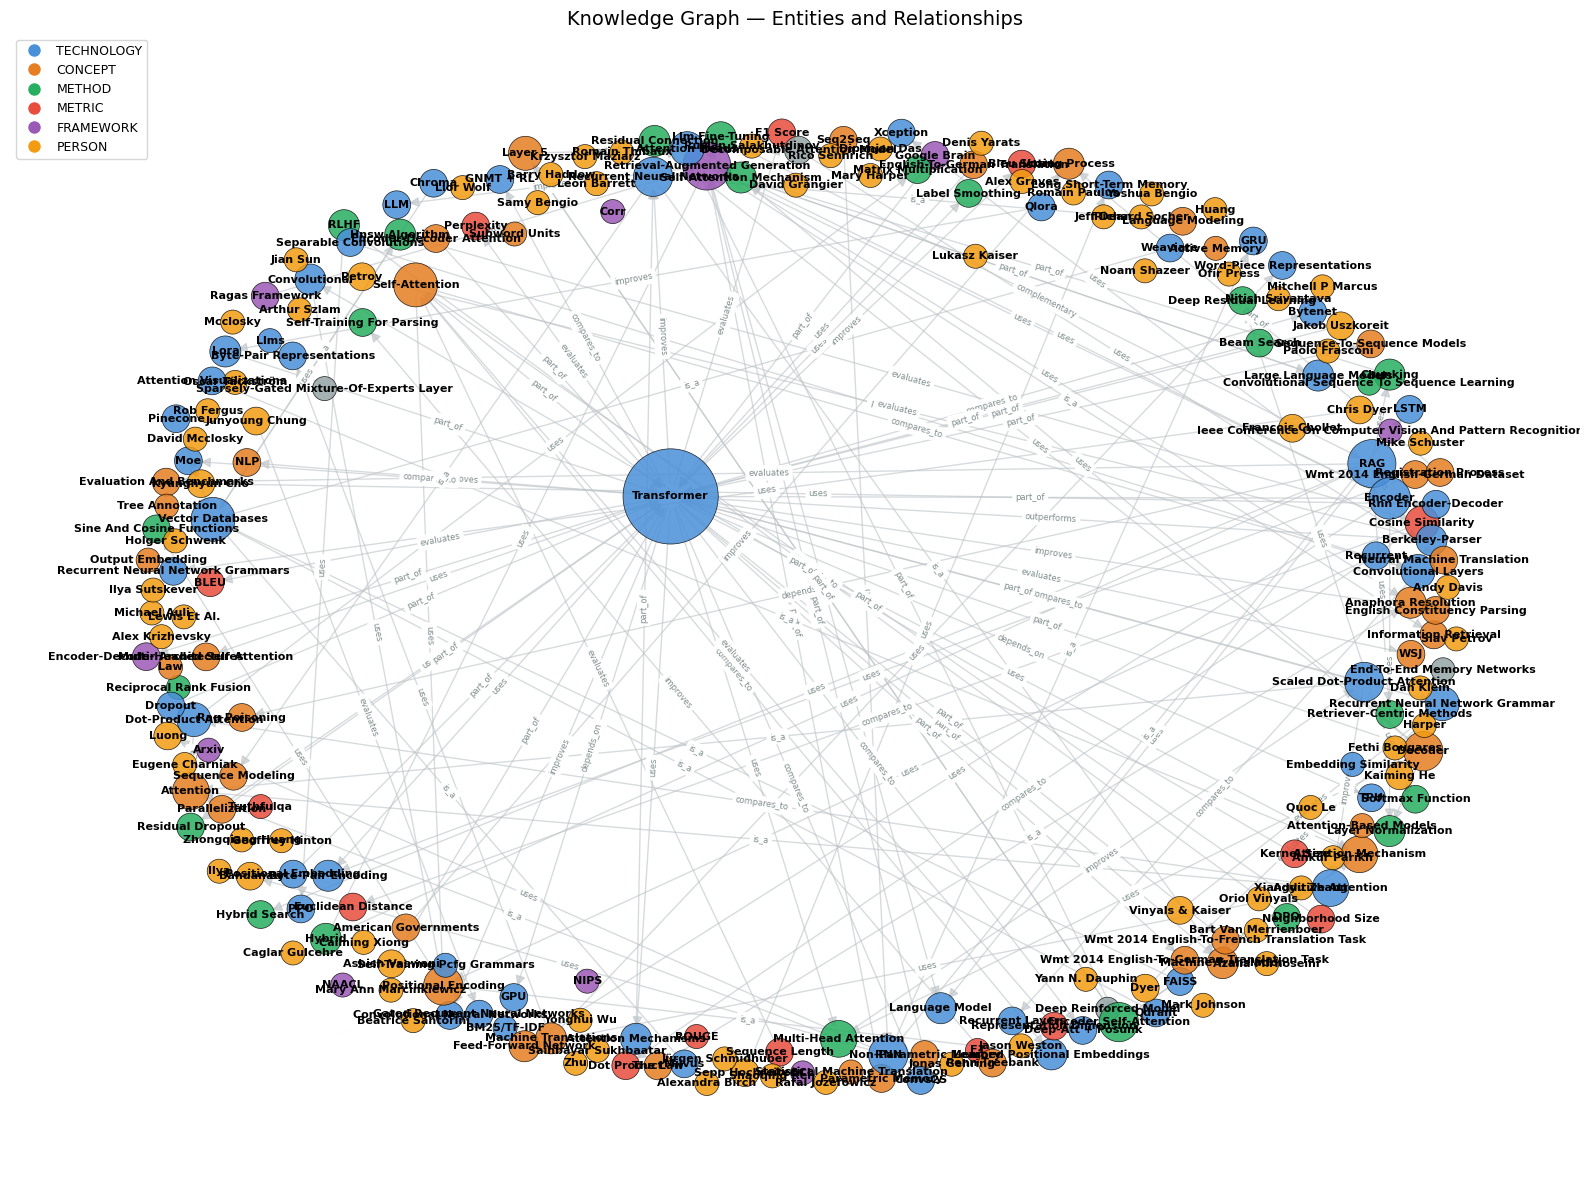

In [40]:
# ── Visualize the Knowledge Graph ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Color nodes by type
type_colors = {
    "TECHNOLOGY": "#4A90D9",
    "CONCEPT": "#E67E22",
    "METHOD": "#27AE60",
    "METRIC": "#E74C3C",
    "FRAMEWORK": "#9B59B6",
    "PERSON": "#F39C12",
}

node_colors = [type_colors.get(kg.nodes[n].get("type", ""), "#95A5A6")
               for n in kg.nodes()]
node_sizes = [300 + 100 * kg.degree(n) for n in kg.nodes()]

pos = nx.spring_layout(kg, k=2.0, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=0.5, ax=ax)

# Draw edges
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)

# Draw labels
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Draw edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in kg.edges(data=True)}
nx.draw_networkx_edge_labels(kg, pos, edge_labels, font_size=6,
                              font_color="#7F8C8D", ax=ax)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=10, label=label)
    for label, color in type_colors.items()
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Entities and Relationships", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 3 — Détection de communautés et résumés

Microsoft GraphRAG introduit une idée clé : après extraction, le graphe est **segmenté en communautés** (algorithme de Leiden / Louvain) — sous-graphes densément connectés.

- Chaque communauté reçoit un **résumé LLM** (niveau local).
- Les communautés sont agrégées en **résumés globaux** (niveau corpus).
- Le retrieval route la question vers le **bon niveau** (local vs global).

Ici on utilise la **modularité** (NetworkX) comme approximation open-source de Leiden.

In [41]:
from networkx.algorithms.community import greedy_modularity_communities


def detect_communities(G: nx.DiGraph) -> List[set]:
    """Detect communities in the knowledge graph."""
    # Convert to undirected for community detection
    G_undirected = G.to_undirected()
    communities = list(greedy_modularity_communities(G_undirected))
    return communities


def summarize_community(G: nx.DiGraph, community: set) -> str:
    """Generate a text summary of a community's entities and relationships."""
    entities_info = []
    for node in community:
        data = G.nodes[node]
        entities_info.append(f"- {node} ({data.get('type', 'UNKNOWN')})")

    relations_info = []
    for u, v, data in G.edges(data=True):
        if u in community and v in community:
            relations_info.append(f"- {u} --[{data['relation']}]--> {v}")

    summary = f"Community with {len(community)} entities:\n"
    summary += "Entities:\n" + "\n".join(entities_info) + "\n"
    if relations_info:
        summary += "Relationships:\n" + "\n".join(relations_info)
    return summary


# Detect communities
communities = detect_communities(kg)
print(f"Detected {len(communities)} communities\n")

community_summaries = []
for i, comm in enumerate(communities):
    summary = summarize_community(kg, comm)
    community_summaries.append({"community_id": i, "entities": comm, "summary": summary})
    print(f"Community {i+1}: {sorted(comm)}")
    print(f"  Size: {len(comm)} entities")
    print()

Detected 111 communities

Community 1: ['Ashish Vaswani', 'Attention Mechanisms', 'BLEU', 'Beam Search', 'Berkeley-Parser', 'Bleu Score', 'Bytenet', 'Convolutional Neural Networks', 'Convs2S', 'Deep-Att + Posunk', 'Dropout', 'Encoder-Decoder Architectures', 'Encoder-Decoder Attention', 'English Constituency Parsing', 'English-To-German Translation', 'F1 Score', 'GNMT + RL', 'GPU', 'Google Brain', 'Jakob Uszkoreit', 'Label Smoothing', 'Language Modeling', 'Lora', 'Machine Translation', 'Moe', 'Multi-Headed Self-Attention', 'NLP', 'Parallelization', 'Perplexity', 'Petrov', 'Positional Embedding', 'Qlora', 'Recurrent Neural Networks', 'Residual Dropout', 'Sequence Modeling', 'Sequence-To-Sequence Models', 'TPU', 'Transformer', 'WSJ', 'Wmt 2014 English-To-French Translation Task', 'Wmt 2014 English-To-German Translation Task']
  Size: 41 entities

Community 2: ['Chunking', 'Evaluation And Benchmarks', 'Hybrid', 'Hybrid Search', 'Information Retrieval', 'LLM', 'Language Model', 'Large Langu

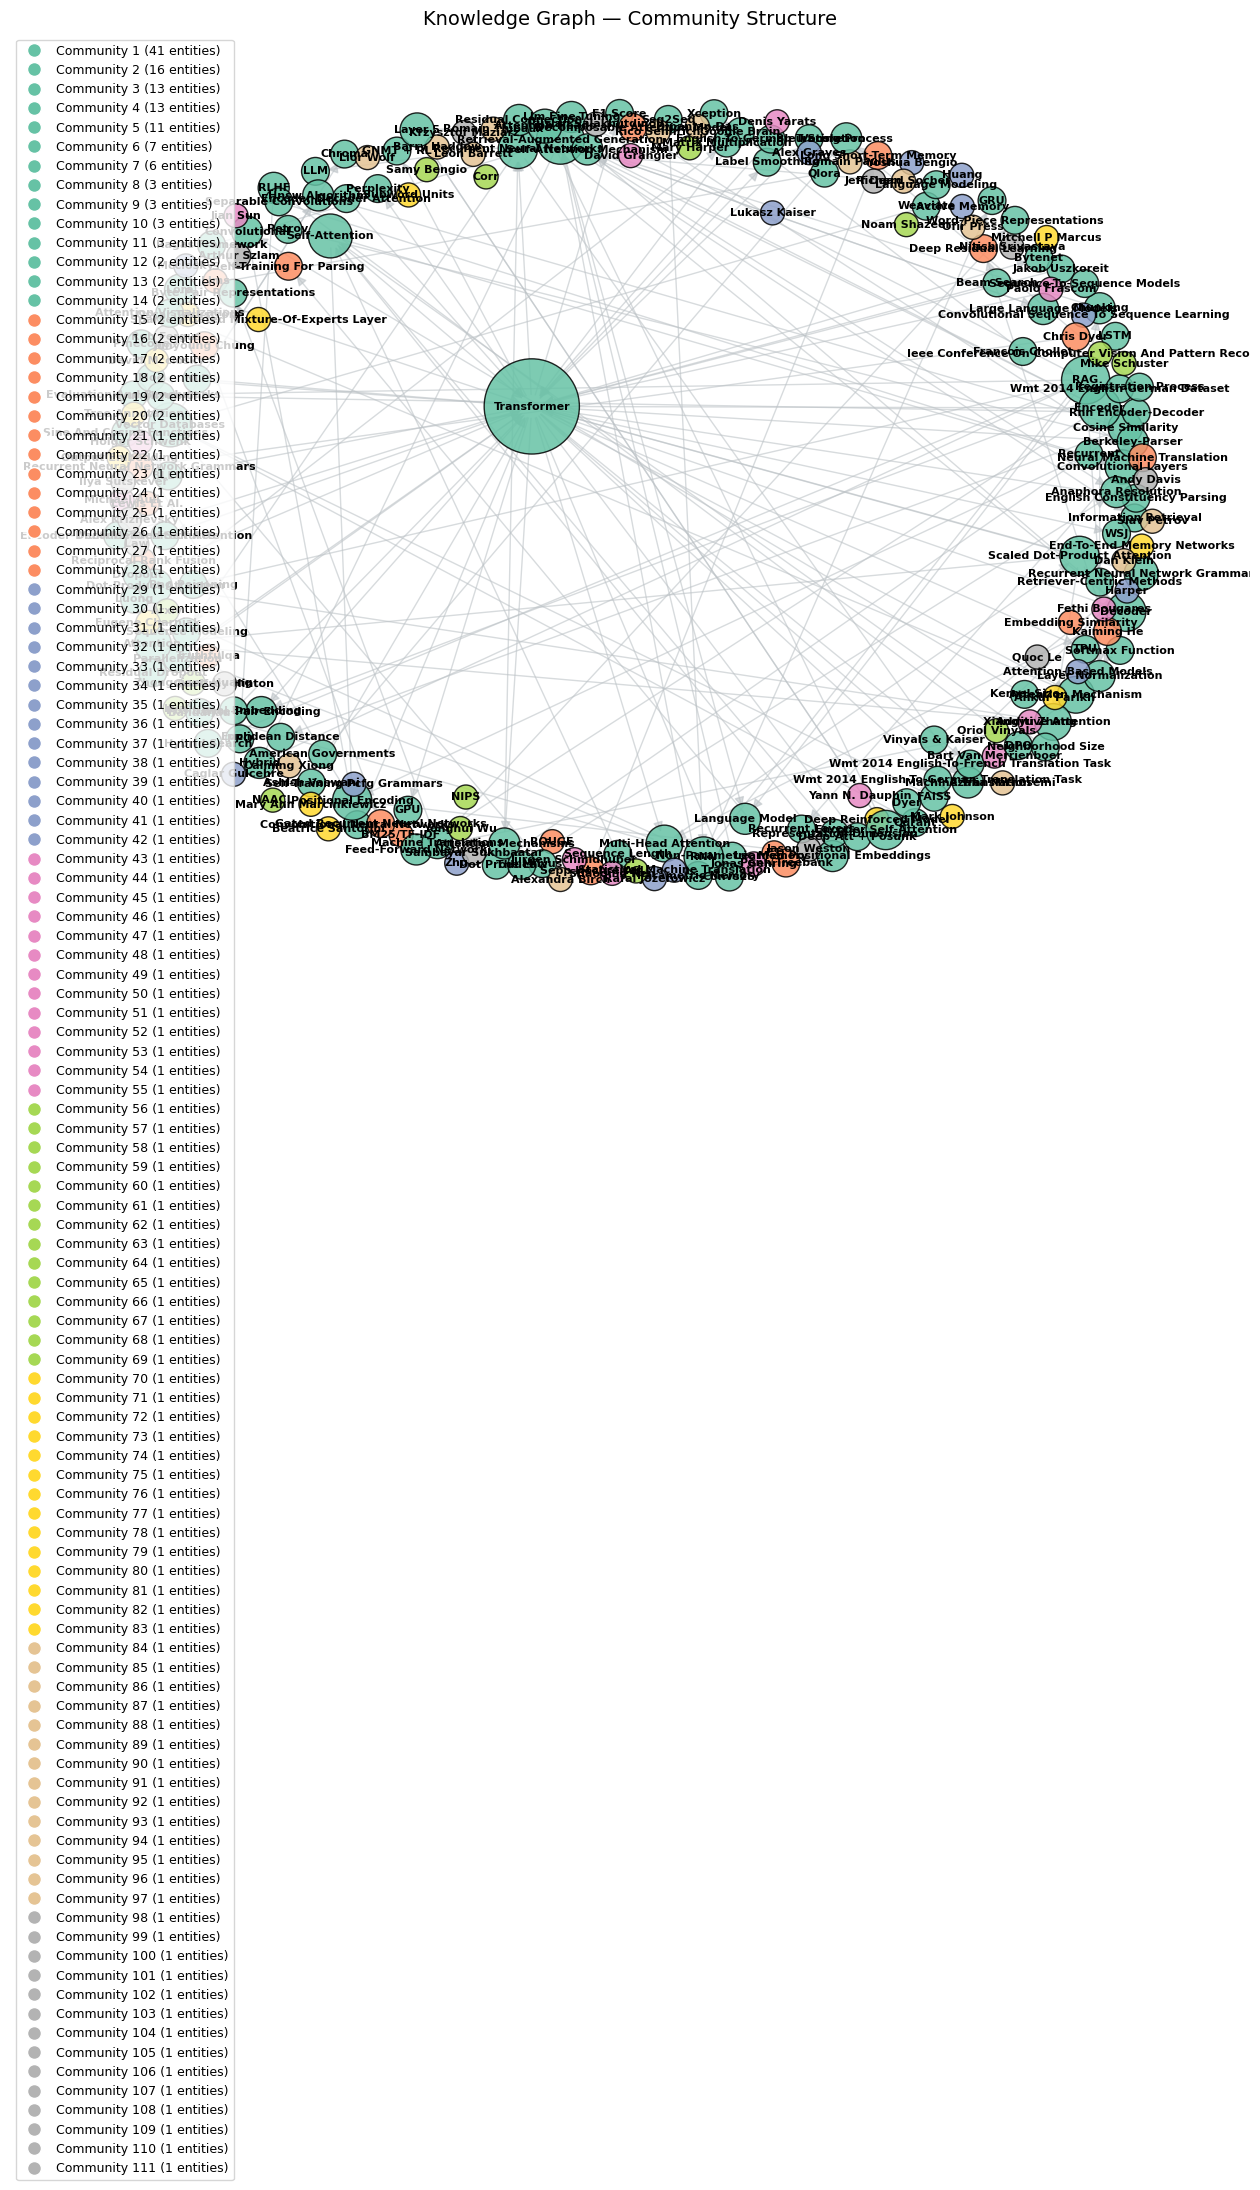

In [42]:
# ── Visualize communities ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Assign colors by community
community_colors = plt.cm.Set2(np.linspace(0, 1, max(len(communities), 2)))
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

node_colors_comm = [community_colors[node_to_community.get(n, 0)] for n in kg.nodes()]

nx.draw_networkx_nodes(kg, pos, node_color=node_colors_comm, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Legend for communities
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=community_colors[i],
               markersize=10, label=f"Community {i+1} ({len(comm)} entities)")
    for i, comm in enumerate(communities)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Community Structure", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 4 — Retrieval graphe : local vs global

Graph RAG supporte deux stratégies de retrieval :

| Stratégie | Fonctionnement | Idéal pour |
|-----------|---------------|------------|
| **Local** | Identifier les entités ancres dans la requête → traverser le voisinage 1–2 hops | Questions sur entité précise |
| **Global** | Router via les résumés de communautés → récupérer les clusters pertinents | Questions thématiques larges |

Nous implémentons les deux modes.

In [43]:
def find_anchor_entities(query: str, graph: nx.DiGraph, threshold: float = 0.4) -> List[str]:
    """Find entities mentioned in the query using embedding similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    node_names = list(graph.nodes())
    node_embs = embed_model.encode(node_names, normalize_embeddings=True)

    similarities = np.dot(query_emb, node_embs.T)[0]
    anchors = [(node_names[i], similarities[i])
               for i in range(len(node_names)) if similarities[i] > threshold]
    anchors.sort(key=lambda x: -x[1])
    return anchors


def retrieve_local_graph(query: str, graph: nx.DiGraph, hops: int = 2,
                          max_entities: int = 5) -> Dict:
    """Local graph retrieval: find anchor entities and traverse their neighborhood."""
    anchors = find_anchor_entities(query, graph)
    if not anchors:
        return {"entities": [], "triples": [], "context": "No relevant entities found."}

    # Collect neighborhood
    relevant_nodes = set()
    for anchor_name, _ in anchors[:max_entities]:
        if anchor_name in graph:
            relevant_nodes.add(anchor_name)
            # BFS up to `hops` steps
            for _ in range(hops):
                neighbors = set()
                for n in relevant_nodes:
                    neighbors.update(graph.successors(n))
                    neighbors.update(graph.predecessors(n))
                relevant_nodes.update(neighbors)

    # Collect triples from subgraph
    triples = []
    for u, v, data in graph.edges(data=True):
        if u in relevant_nodes and v in relevant_nodes:
            triples.append((u, data["relation"], v))

    # Build context string
    context_lines = [f"Entities: {', '.join(sorted(relevant_nodes))}"]
    context_lines.append("\nRelationships:")
    for s, r, o in triples:
        context_lines.append(f"  - {s} --[{r}]--> {o}")

    return {
        "entities": sorted(relevant_nodes),
        "triples": triples,
        "anchors": [(a, round(s, 3)) for a, s in anchors[:max_entities]],
        "context": "\n".join(context_lines),
    }


def retrieve_global_graph(query: str, communities: List[Dict],
                           top_k: int = 2) -> Dict:
    """Global graph retrieval: find relevant communities via summary similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    summaries = [c["summary"] for c in communities]
    summary_embs = embed_model.encode(summaries, normalize_embeddings=True)

    similarities = np.dot(query_emb, summary_embs.T)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    relevant_communities = []
    for idx in top_indices:
        relevant_communities.append({
            "community_id": communities[idx]["community_id"],
            "similarity": float(similarities[idx]),
            "summary": communities[idx]["summary"],
            "entities": communities[idx]["entities"],
        })

    context = "\n\n".join([
        f"[Community {c['community_id']+1}]\n{c['summary']}"
        for c in relevant_communities
    ])

    return {
        "communities": relevant_communities,
        "context": context,
    }


print("Graph retrieval functions defined.")

Graph retrieval functions defined.


In [44]:
# ── Test local graph retrieval ────────────────────────────────────────────
query = "How does the Transformer architecture relate to BERT and GPT?"
print(f"Query: '{query}'\n")

local_result = retrieve_local_graph(query, kg)
print(f"Anchor entities (with similarity):")
for name, score in local_result["anchors"]:
    print(f"  - {name} ({score:.3f})")

print(f"\nSubgraph: {len(local_result['entities'])} entities, "
      f"{len(local_result['triples'])} relationships")
print(f"\nContext for LLM:")
print(local_result["context"])

Query: 'How does the Transformer architecture relate to BERT and GPT?'

Anchor entities (with similarity):
  - Transformer (0.463)

Subgraph: 68 entities, 79 relationships

Context for LLM:
Entities: Additive Attention, Ashish Vaswani, Attention, Attention Mechanism, Attention Mechanisms, Attention Visualizations, BLEU, Beam Search, Berkeley-Parser, Bleu Score, Byte-Pair Encoding, Bytenet, Convolutional Layers, Convolutional Neural Networks, Convs2S, Decoder, Deep-Att + Posunk, Dropout, Dyer, Encoder, Encoder Self-Attention, Encoder-Decoder Architectures, Encoder-Decoder Attention, English Constituency Parsing, English-To-German Translation, F1 Score, Feed-Forward Network, GNMT + RL, GPU, Google Brain, Jakob Uszkoreit, Label Smoothing, Language Modeling, Layer Normalization, Learned Positional Embeddings, Lora, Machine Translation, Moe, Multi-Head Attention, Multi-Headed Self-Attention, NLP, Neighborhood Size, Parallelization, Perplexity, Petrov, Positional Embedding, Positional Encodi

In [45]:
# ── Test global graph retrieval ───────────────────────────────────────────
query = "What are the main evaluation approaches for AI systems?"
print(f"Query: '{query}'\n")

global_result = retrieve_global_graph(query, community_summaries)
for c in global_result["communities"]:
    print(f"Community {c['community_id']+1} (similarity: {c['similarity']:.3f}):")
    print(f"  Entities: {sorted(c['entities'])}")
    print()

Query: 'What are the main evaluation approaches for AI systems?'

Community 6 (similarity: 0.312):
  Entities: ['Anaphora Resolution', 'Attention Heads', 'Attention Mechanism', 'Attention Visualizations', 'Encoder Self-Attention', 'Layer 5', 'The Law']

Community 2 (similarity: 0.308):
  Entities: ['Chunking', 'Evaluation And Benchmarks', 'Hybrid', 'Hybrid Search', 'Information Retrieval', 'LLM', 'Language Model', 'Large Language Models', 'Llm Fine-Tuning', 'Non-Parametric Memory', 'Parametric Memory', 'RAG', 'Rag Poisoning', 'Ragas Framework', 'Retrieval-Augmented Generation', 'Retriever-Centric Methods']



## Étape 5 — Graph RAG hybride (graphe + vecteur)

L'approche la plus puissante combine :
- **Retrieval graphe** — structure relationnelle, multi-hop explicite
- **Retrieval vectoriel** — flexibilité sémantique, détails depuis le texte original

Le graphe fournit les relations structurées ; la base vectorielle remplit les détails depuis le texte. On fusionne au niveau du prompt.

In [46]:
def graph_rag_pipeline(query: str, graph: nx.DiGraph,
                        community_summaries: List[Dict],
                        top_k_vector: int = 3, top_k_graph: int = 3) -> Dict:
    """Full Graph RAG pipeline: graph + vector retrieval → augmented generation."""

    # 1. Local graph retrieval (entity neighborhood)
    local_result = retrieve_local_graph(query, graph)

    # 2. Global graph retrieval (community summaries)
    global_result = retrieve_global_graph(query, community_summaries, top_k=2)

    # 3. Vector retrieval (original chunk text)
    vector_results = retrieve_hybrid(query, top_k=top_k_vector)
    vector_reranked = rerank(query, vector_results, top_k=top_k_vector)

    # 4. Build combined prompt
    graph_context = (
        "=== Knowledge Graph Context ===\n"
        f"{local_result['context']}\n\n"
        "=== Community Summaries ===\n"
        f"{global_result['context']}"
    )

    vector_context = "\n\n---\n\n".join([
        f"[Chunk from {r['metadata'].get('source', '?')}]\n{r['text']}"
        for r in vector_reranked
    ])

    prompt = f"""You are an expert assistant with access to both a knowledge graph and document chunks.

Rules:
- Answer ONLY from the provided context (graph + documents).
- If evidence is insufficient, say: "Insufficient evidence in the provided context."
- Cite sources when possible.
- Leverage the knowledge graph for relationships between entities.
- Use document chunks for detailed explanations.

{graph_context}

=== Document Chunks ===
{vector_context}

Question: {query}

Answer:"""

    # 5. Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "graph_entities": local_result["entities"],
        "graph_triples": local_result["triples"],
        "vector_chunks": len(vector_reranked),
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print("Graph RAG pipeline ready.")

Graph RAG pipeline ready.


In [47]:
# ── Test Graph RAG on relational questions ────────────────────────────────
graph_rag_queries = [
    "How does the Transformer architecture relate to BERT, GPT, and T5?",
    "What methods improve RAG retrieval quality?",
    "Compare LoRA and QLoRA for fine-tuning.",
    "What vector databases use HNSW and what are the alternatives?",
]

for q in graph_rag_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    result = graph_rag_pipeline(q, kg, community_summaries)

    print(f"\nGraph entities used: {result['graph_entities'][:8]}")
    print(f"Graph triples: {len(result['graph_triples'])} | "
          f"Vector chunks: {result['vector_chunks']} | "
          f"Prompt: {result['prompt_tokens']} tokens")
    print(f"\nAnswer:")
    print(result["answer"])


Q: How does the Transformer architecture relate to BERT, GPT, and T5?

Graph entities used: ['Additive Attention', 'Ashish Vaswani', 'Attention', 'Attention Mechanism', 'Attention Mechanisms', 'Attention Visualizations', 'BLEU', 'Beam Search']
Graph triples: 79 | Vector chunks: 3 | Prompt: 4140 tokens

Answer:
The Transformer architecture is the foundation for many subsequent models, including BERT, GPT, and T5. According to the document chunk from transformers.md, the Transformer's encoder-decoder architecture was later deconstructed and modified to create various specialized models. BERT, for example, is an "encodeur-seul" (encoder-only) model that suppresses the decoder and uses a bidirectional encoder to achieve deep understanding of language. GPT and T5 are also based on the Transformer architecture, but with different modifications and specializations. 

As stated in the document chunk, "L'architecture encodeur-décodeur de 2017... s'est avérée être un outil générique aux applica

---

## D.6 — Comparaison Vector RAG vs Graph RAG (sur les mêmes questions)

On compare comment **Vector RAG** (Partie A) et **Graph RAG** (Partie D) traitent les **mêmes** questions, avec un focus sur les questions **relationnelles** où le graphe est censé exceller.

### Tableau de décision (rappel)

| Type de question | Vector RAG | Graph RAG | Hybride (recommandé) |
|---|:---:|:---:|:---:|
| Factuelle isolée | ✅ | ⚠️ | ✅ |
| Résumé d'un document | ✅ | ⚠️ | ✅ |
| Multi-hop / relationnelle | ❌ | ✅ | ✅ |
| Requête globale sur corpus | ❌ | ✅ | ✅ |
| Paraphrases / synonymes | ✅ | ⚠️ | ✅ |

**Heuristique de routage :**
- *« Qui »*, *« quoi »*, *« combien »* isolés → **Vector**
- *« Comment X est lié à Y »*, *« tous les… »*, *« via Z »* → **Graph**
- En cas de doute, ou audience mixte → **Hybride** (notre `graph_rag_pipeline`)


In [48]:
# ── Side-by-side comparison ───────────────────────────────────────────────
comparison_queries = [
    # Relational question (Graph RAG should excel)
    "What is the relationship between Transformer, self-attention, and BERT?",
    # Factual question (Classic RAG should be sufficient)
    "What is the recommended chunk size for RAG systems?",
]

for q in comparison_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    # Classic RAG
    classic_result = rag_pipeline_full(q, retrieval_method="hybrid")
    print(f"\n--- Classic RAG ({classic_result['prompt_tokens']} tokens) ---")
    print(classic_result["answer"])

    # Graph RAG
    graph_result = graph_rag_pipeline(q, kg, community_summaries)
    print(f"\n--- Graph RAG ({graph_result['prompt_tokens']} tokens) ---")
    print(graph_result["answer"])


Q: What is the relationship between Transformer, self-attention, and BERT?

--- Classic RAG (1309 tokens) ---
The Transformer architecture relies entirely on self-attention to compute representations of its input and output [Source 1]. Self-attention is a key component of the Transformer, allowing each word in a sequence to connect directly to any other word [Source 2]. The Transformer's use of self-attention has led to state-of-the-art results in translation and has laid the foundations for modern generative AI, including BERT [Source 2].

--- Graph RAG (3845 tokens) ---
The Transformer architecture, which relies entirely on self-attention to compute representations of its input and output, has been instrumental in the development of modern language models like BERT. As stated in the document chunk from transformers.md, "Ce changement de paradigme a non seulement pulvérisé les scores de l'état de l'art en traduction automatique, mais a posé les fondations algorithmiques de l'intellig

## Analyse coût / bénéfice du Graph RAG

In [49]:
# ── Summarize the tradeoffs ───────────────────────────────────────────────
comparison_data = {
    "Aspect": [
        "Setup complexity",
        "Ingestion cost",
        "Handles relationships",
        "Simple factual Q&A",
        "Multi-hop reasoning",
        "Maintenance burden",
        "Retrieval latency",
    ],
    "Classic RAG": ["Low", "Low", "Weak", "Strong", "Weak", "Low", "Fast"],
    "Graph RAG": ["High", "High (LLM extraction)", "Strong", "Strong", "Strong", "High", "Medium"],
}

print(f"{'Aspect':<25} {'Classic RAG':<20} {'Graph RAG':<20}")
print(f"{'-'*65}")
for i in range(len(comparison_data["Aspect"])):
    print(f"{comparison_data['Aspect'][i]:<25} "
          f"{comparison_data['Classic RAG'][i]:<20} "
          f"{comparison_data['Graph RAG'][i]:<20}")

print("\nDecision rule:")
print("  Use Graph RAG when relational structure is CENTRAL to user questions.")
print("  Default to Classic RAG for simpler use cases — lower cost, faster iteration.")

Aspect                    Classic RAG          Graph RAG           
-----------------------------------------------------------------
Setup complexity          Low                  High                
Ingestion cost            Low                  High (LLM extraction)
Handles relationships     Weak                 Strong              
Simple factual Q&A        Strong               Strong              
Multi-hop reasoning       Weak                 Strong              
Maintenance burden        Low                  High                
Retrieval latency         Fast                 Medium              

Decision rule:
  Use Graph RAG when relational structure is CENTRAL to user questions.
  Default to Classic RAG for simpler use cases — lower cost, faster iteration.


---

# Synthèse

## Ce que vous avez construit

| Étape | Ce que vous avez fait | Brique LangChain | Enseignement clé |
|---|---|---|---|
| **Loading** | PDF, Markdown, Web → `Document` uniformes | `PyPDFLoader`, `WebBaseLoader`, `UnstructuredMarkdownLoader` | Métadonnées critiques pour le filtrage et la citation |
| **Chunking** | Récursif tokens + structure Markdown + Contextual Retrieval | `RecursiveCharacterTextSplitter`, `MarkdownHeaderTextSplitter` | Chunking = levier qualité n°1 |
| **Embeddings** | Bi-encoder (MiniLM) + démo similarité | `sentence-transformers` | Open-source, normaliser pour cosine = dot |
| **Vector Storage** | Chroma + BM25 (HNSW vs IVF expliqué) | `chromadb`, `rank_bm25` | Hybride par défaut en prod |
| **Retrieval** | Dense / Sparse / Hybride (RRF) | — | RRF surpasse régulièrement les méthodes seules |
| **Reranking** | Cross-encoder (vs Bi-encoder expliqué) | `sentence-transformers/CrossEncoder` | +10 à +30 % Faithfulness à coût modéré |
| **Génération** | `llama-3.3-70b-versatile` via Groq (Python pur) | — | API OpenAI-compatible, gratuit, ultra-rapide |
| **Advanced** | Lost-in-the-middle, Query Rewriting, Multi-Query, HyDE | — | À combiner selon les types de requêtes |
| **Évaluation** | RAGas (Faithfulness, Relevancy, Precision, Recall) | `ragas` + `langchain-groq` | LLM-as-a-judge — itératif et mesurable |
| **Observabilité** | Trace LangSmith (cellule prête) | `langsmith` | 80 % des bugs = retrieval invisible |
| **Graph RAG (bonus)** | Extraction → KG → communautés → retrieval local/global | `networkx` | Supérieur sur les questions relationnelles |

## Principes clés

1. **« Garbage retrieval in, garbage answer out. »** La qualité du retrieval **borne** la qualité de la réponse.
2. **Chunker intelligemment.** Les plus gros gains viennent du chunking + reranking, pas du LLM.
3. **L'orchestration en Python pur, c'est la transparence.** LangChain pour les briques, pas pour l'orchestration.
4. **Évaluer en continu.** Golden set + RAGas + LangSmith = le triptyque indispensable.
5. **L'hybride est le standard.** Sparse + dense + reranker = baseline production.
6. **Graph RAG quand c'est nécessaire.** Puissant pour les relations, overkill pour les FAQ simples.

## Exercices pour aller plus loin

1. **Réglage de `chunk_size`** ∈ {128, 256, 512, 1024} → mesurer Context Precision / Recall avec RAGas.
2. **Comparer 2 modèles d'embedding** : `all-MiniLM-L6-v2` (384D, EN) vs `multilingual-e5-large` (1024D, multilingue) sur un corpus FR.
3. **Activer Multi-Query + HyDE en cascade** sur les requêtes courtes (< 5 mots) uniquement.
4. **Filtrage par métadonnées** au retrieval : `where={"format": "pdf", "year": "2024"}`.
5. **Cache sémantique** : indexer les paires (question_emb, réponse). Si une nouvelle requête a un cosinus > 0.95 avec une question existante, renvoyer la réponse cachée.
6. **Routeur agentique** : un classifieur LLM décide, par requête, quoi activer (Multi-Query ? HyDE ? Graph ?).
7. **Étendre le graphe** (Partie D) : ajouter 5 nouveaux PDF, observer la croissance des communautés.
8. **Tester un autre modèle Groq** : remplacer `llama-3.3-70b-versatile` par `llama-3.1-8b-instant` (plus rapide, moins précis) ou `mixtral-8x7b-32768` — comparer Faithfulness.
